# 03 — NMF em Folha de São Paulo (PT-BR)

## O que esse notebook faz

Aplica **Non-negative Matrix Factorization (NMF)**, via `gensim.models.Nmf`, ao corpus Folha de São Paulo. Espelha o protocolo de investigação de duas etapas usado no LDA (`02_lda_folha.ipynb`) — grid de K por coerência C_v, depois grid de hiperparâmetros (`kappa` × `minimum_probability`, análogo a alpha/eta do LDA) com K fixo — trocando o algoritmo probabilístico (LDA) por fatoração não-negativa da matriz documento-termo.

**Corpus:** Folha de São Paulo — PT-BR, formal/jornalístico, 2018-2024.
**Entrada:** `data/input/folha/corpus_limpo.csv`


## 1. Setup e imports

Carregamos parâmetros do `configs/params.yaml` (entrada `corpora.folha`), o seed global e as funções dos pipelines reusáveis:

- `_helpers.lemmatize_corpus(docs, lang, params, model_key="nmf")` → tokens lematizados + Dictionary com filter_extremes (bloco `nmf:`)
- `_helpers.grid_search_k_nmf / grid_search_nmf_hparams / train_nmf / extract_topics_keywords / compute_doc_distributions` → fit e extração
- `_helpers.name_all_topics` → rotulagem via Ollama (modelo em `params.yaml`)
- `_helpers.*` → métricas (c_v, exclusivity, FREX, NPMI, etc.) — compartilhadas com o LDA


In [1]:
# ── path fix: resolve _helpers.py e data/ de qualquer subdiretório ──
import sys as _sys, os as _os
from pathlib import Path as _P
_here = _P().resolve()
_nb_dir = _here if (_here / '_helpers.py').exists() else _here.parent
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))
_os.chdir(_nb_dir)          # '../data/...' paths ficam corretos
del _here, _nb_dir, _P, _sys, _os
# ─────────────────────────────────────────────────────────────────────
# Cell 1 — Imports
import sys, os, json, time, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from gensim.models import Nmf

from _helpers import load_params, get_corpus_config, get_seed, load_corpus
from _helpers import lemmatize_corpus
from _helpers import (
    grid_search_k_nmf, grid_search_nmf_hparams, train_nmf, extract_topics_keywords,
    compute_doc_distributions, qualitative_report,
    compute_nmf_reconstruction_error, cache_protocolo_apto,
)
from _helpers import name_all_topics, name_topic
from _helpers import (
    compute_coherence_cv, compute_exclusivity, compute_exclusivity_ctfidf, compute_diversity,
    compute_topic_diversity, compute_frex_score, compute_stability,
    export_results, export_topics_for_eval,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


d:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2 — Carrega params do params.yaml
CORPUS_ID = "folha"
LANG = "pt"

params = load_params()
_, cfg = get_corpus_config(params, CORPUS_ID)
seed = get_seed(params)
TEXT_COL = cfg["text_column"]

print(f"corpus_id = {CORPUS_ID}")
print(f"text_column = {TEXT_COL}")
print(f"language = {LANG}")
print(f"seed = {seed}")
print(f"covariates (usadas no STM, não no NMF) = {cfg.get('covariates', [])}")


corpus_id = folha
text_column = message
language = pt
seed = 42
covariates (usadas no STM, não no NMF) = ['date', 'category']


## 2. Corpus Folha de São Paulo

### Origem e schema
- **Fonte:** CSV em `data/raw/folha/`
- **Idioma:** PT-BR, formal/jornalístico, 2018-2024
- **Schema:** `post_id`, `message`, `date`, `category` (editoria)




In [3]:
# Cell 3 — Carrega corpus_limpo.csv
# Resolve o corpus direto do output do 01-preprocessing (latest-wins, sem copia)
from _helpers import resolve_latest_dir
_corpus_dir = resolve_latest_dir(
    f"../../01-preprocessing/data/output/{CORPUS_ID}",
    contains="corpus_limpo.csv",
    fallback_dir=f"../data/input/{CORPUS_ID}",
)
CORPUS_VERSION = _corpus_dir.name
print(f"Versao do corpus: {CORPUS_VERSION}")
df = load_corpus(_corpus_dir)
docs = df[TEXT_COL].astype(str).tolist()
post_ids = df["post_id"].astype(str).tolist()

# Subsample 5k (mesma seed=42 do BERTopic — treino e métricas no mesmo conjunto)
_s_idx = np.random.RandomState(42).choice(len(docs), min(5000, len(docs)), replace=False)
df = df.iloc[_s_idx].reset_index(drop=True)
docs = df[TEXT_COL].astype(str).tolist()
post_ids = df["post_id"].astype(str).tolist()
print(f"Total docs: {len(docs):,} (subsample seed=42, padronizado com BERTopic)")
print(f"Colunas: {list(df.columns)}")
df.head(3)


  versão resolvida: folha_20260628_185652/ (latest)
Versao do corpus: folha_20260628_185652
Carregado: corpus_limpo.csv (4939 docs, SEM coluna 'sentiment' — rode 03-sentiment antes para ter cruzamento topic x sentiment automatico)
Total docs: 4,939 (subsample seed=42, padronizado com BERTopic)
Colunas: ['post_id', 'message', 'message_raw', 'title', 'data', 'category', 'platform']


,post_id,message,message_raw,title,data,category,platform
0,post_1972,A China se prepara para vacinar crianças a par...,A China se prepara para vacinar crianças a par...,China pretende aplicar a vacina Coronavac em c...,2021-06-09 13:15:00.0000000,equilibrioesaude,folha_uol
1,post_4567,Quatro meses antes de deixar prescrever um pro...,Quatro meses antes de deixar prescrever um pro...,Justiça deixou prescrever processo contra Edir...,2019-11-26 08:00:00.0000000,poder,folha_uol
2,post_0151,Não é normal que chimpanzés andem como os huma...,Não é normal que chimpanzés andem como os huma...,Os chimpanzés que caminham como humanos após a...,2019-08-01 11:53:00.0000000,ambiente,folha_uol


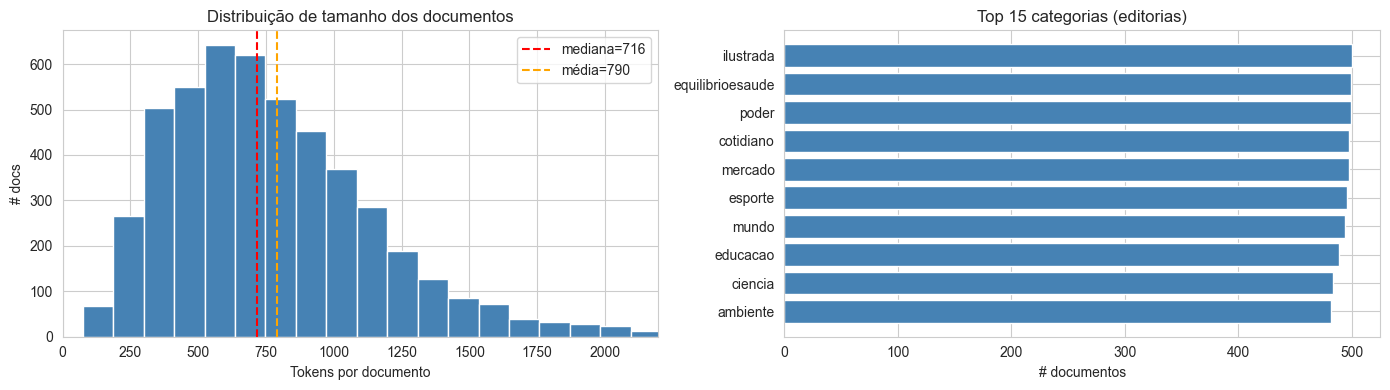


Descritivas n_tokens: {'count': 4939.0, 'mean': 790.0696497266653, 'std': 437.76195838317363, 'min': 75.0, '25%': 494.0, '50%': 716.0, '75%': 992.5, 'max': 6806.0}


In [4]:
# Cell 4 — Estatisticas descritivas + distribuicao de tokens
df["n_tokens"] = df["message"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["n_tokens"], bins=60, edgecolor="white", color="steelblue")
axes[0].axvline(df["n_tokens"].median(), color="red", linestyle="--", label=f'mediana={df["n_tokens"].median():.0f}')
axes[0].axvline(df["n_tokens"].mean(), color="orange", linestyle="--", label=f'média={df["n_tokens"].mean():.0f}')
axes[0].set_xlabel("Tokens por documento"); axes[0].set_ylabel("# docs")
axes[0].set_title("Distribuição de tamanho dos documentos"); axes[0].legend()
axes[0].set_xlim(0, df["n_tokens"].quantile(0.99))

cat_counts = df["category"].value_counts().head(15)
axes[1].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="steelblue")
axes[1].set_xlabel("# documentos"); axes[1].set_title("Top 15 categorias (editorias)")
plt.tight_layout(); plt.show()

print(f"\nDescritivas n_tokens: {df['n_tokens'].describe().to_dict()}")


## 3. Lematização e construção do vocabulário

### O que `_helpers.lemmatize_corpus` faz

1. Carrega spaCy `pt_core_news_lg` (cached em module-level)
2. Para cada doc: tokeniza, descarta stopwords (lista interna spaCy) + tokens não-alfa + tokens curtos (`len(lemma) <= 2`)
3. Constrói gensim `Dictionary` com `filter_extremes(no_below=5, no_above=0.5)` (parâmetros do bloco `nmf:` em `params.yaml`, via `model_key="nmf"`):
   - Remove palavras que aparecem em <5 docs (raras, ruído)
   - Remove palavras em >50% dos docs (genéricas, sem poder discriminante — ex.: "disse")

### Por que lematizar (vs stemming)

- Lematização preserva forma legível (`correndo` → `correr`; stemming agressivo produziria `corr`)
- Mais interpretável para a banca da dissertação
- Custo: ~30s a ~3min em CPU dependendo do volume
- Mesmo vocabulário do LDA (mesmos `no_below`/`no_above`) — garante comparabilidade direta entre os dois modelos


In [5]:
# Cell 5 — Lematiza corpus
print("Lematizando (single-process spaCy pt_core_news_lg)...")
t0 = time.time()
tokenized, dictionary = lemmatize_corpus(
    docs, LANG, params, model_key="nmf",
    extra_stopwords=cfg.get("nmf_stopwords_extra", []),
)
print(f"  done em {time.time()-t0:.0f}s")
print(f"  vocab final: {len(dictionary):,} palavras (após filter_extremes)")

# Estatísticas dos tokens lemmatizados
n_tokens_lemma = [len(t) for t in tokenized]
n_unique = [len(set(t)) for t in tokenized]

print(f"\n  avg tokens/doc após lemmatize: {np.mean(n_tokens_lemma):.1f}")
print(f"  avg unique tokens/doc: {np.mean(n_unique):.1f}")


Lematizando (single-process spaCy pt_core_news_lg)...
  done em 411s
  vocab final: 17,331 palavras (após filter_extremes)

  avg tokens/doc após lemmatize: 377.1
  avg unique tokens/doc: 240.5


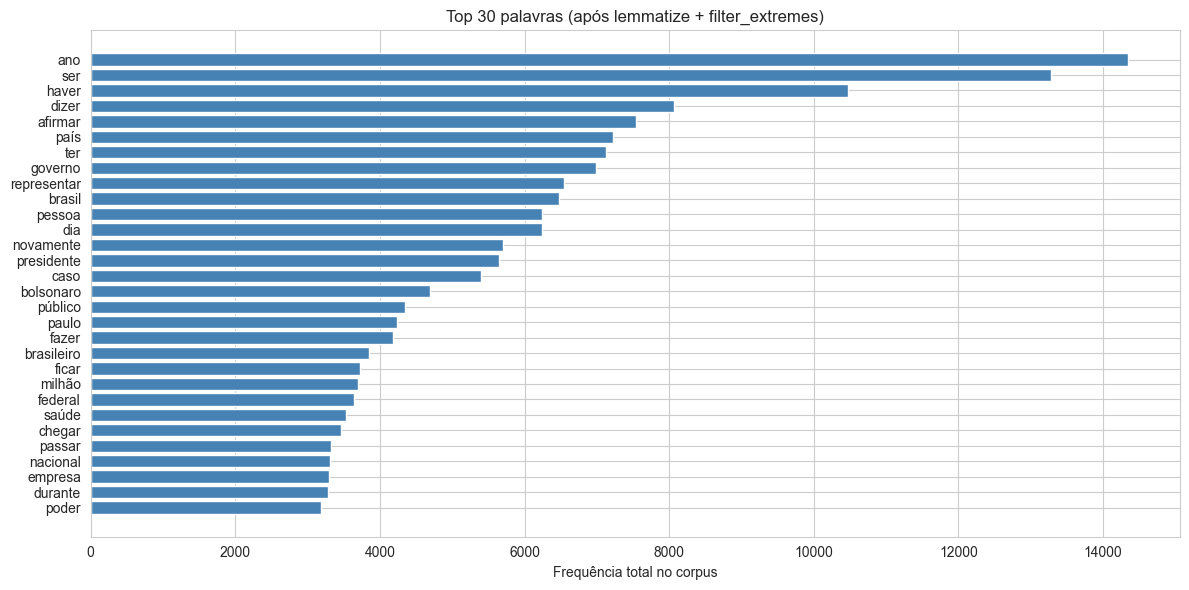

In [6]:
# Cell 6 — Top 30 palavras mais frequentes no vocabulário final
all_tokens = [t for doc in tokenized for t in doc]
freq = Counter(all_tokens)
top30 = freq.most_common(30)

fig, ax = plt.subplots(figsize=(12, 6))
words, counts = zip(*top30)
ax.barh(words[::-1], counts[::-1], color="steelblue")
ax.set_xlabel("Frequência total no corpus")
ax.set_title("Top 30 palavras (após lemmatize + filter_extremes)")
plt.tight_layout(); plt.show()


In [7]:
# Cell 7 — Bag-of-Words representation
corpus_bow = [dictionary.doc2bow(d) for d in tokenized]
print(f"corpus_bow: {len(corpus_bow):,} docs")
print(f"avg unique tokens/doc no BoW: {np.mean([len(b) for b in corpus_bow]):.1f}")
print(f"\nExemplo doc[0] BoW (primeiros 10 pares (word_id, count)):")
for word_id, count in corpus_bow[0][:10]:
    print(f"  {dictionary[word_id]:20s}  count={count}")


corpus_bow: 4,939 docs
avg unique tokens/doc no BoW: 219.2

Exemplo doc[0] BoW (primeiros 10 pares (word_id, count)):
  acesso                count=1
  acrescentar           count=1
  administrar           count=2
  administração         count=1
  adolescente           count=2
  adulto                count=1
  afp                   count=1
  alaska                count=1
  anunciar              count=1
  aplicar               count=2


## 4. Seleção de K (número de tópicos)

### Por que K importa

K é o **único hiperparâmetro estrutural** do NMF (assim como no LDA). Influencia a granularidade dos tópicos:
- K muito baixo → tópicos macro/genéricos (varios temas misturados em um)
- K muito alto → fragmentação (mesmo tema dividido em múltiplos clusters)

### Como escolher

Mesmo protocolo do LDA: rodar NMF em vários K, calcular **c_v coherence** (Roder et al. 2015) — métrica que combina:
- co-ocorrência das top-N palavras numa janela deslizante
- score NPMI normalizado
- agregação via cosine similarity

Limitação conhecida: **c_v penaliza K alto** (Stevens et al. 2012). Por isso complementamos com inspeção qualitativa em múltiplos K (próxima célula). Diferente do LDA, `gensim.models.Nmf` não expõe `log_perplexity` — não há métrica de perplexidade complementar aqui.


In [8]:
# Cell 8 — Grid search K (carrega resultado do run standalone se existir)
from _helpers import make_run_output_dir
BASE_OUTPUT_DIR = Path(f"../data/output/{CORPUS_ID}/nmf")
BASE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Saida carimbada por execucao: <corpus>_<data>_<hora> (nao sobrescreve runs anteriores)
OUTPUT_DIR = make_run_output_dir(BASE_OUTPUT_DIR, CORPUS_ID)
out_dir = str(OUTPUT_DIR)
# Cache do grid search: le/persiste no diretorio-BASE (reutiliza entre runs)
m_path = f"{BASE_OUTPUT_DIR}/nmf_metrics.csv"

# PROTOCOLO 2026-08-16 (C9): cache pegajoso — sob o protocolo o eixo de ordenacao
# do NMF passa a ser o NPMI (secao 4.2.2, mesma regra do LDA), entao um cache sem a
# curva de NPMI esta desatualizado por definicao e precisa ser recomputado.
# ADICAO 2026-08-23: a curva de Diversity (segundo eixo da fronteira de Pareto,
# secao 1.6) tambem invalida o cache — mesma correcao ja aplicada no LDA (Cell 8).
_faltando_no_cache = cache_protocolo_apto(pd.read_csv(m_path), ["k_npmi_scores", "k_diversity_scores"]) \
    if os.path.exists(m_path) else ["k_npmi_scores", "k_diversity_scores"]
if _faltando_no_cache:
    print(f"Cache do grid sem {_faltando_no_cache} (pre-protocolo 2026-08-16/22) — recomputando.")

if os.path.exists(m_path) and not _faltando_no_cache:
    m = pd.read_csv(m_path)
    scores = ast.literal_eval(m.iloc[0]["k_grid_scores"])
    scores = {int(k): float(v) for k, v in scores.items()}
    npmi_scores = {int(k): float(v) for k, v in
                   ast.literal_eval(str(m.iloc[0]["k_npmi_scores"])).items()}
    div_scores = {int(k): float(v) for k, v in
                   ast.literal_eval(str(m.iloc[0]["k_diversity_scores"])).items()}
    print(f"Carregado grid pre-computado de {m_path}")
    print(f"  K range: {sorted(scores.keys())}")
    print(f"  passes: {m.iloc[0].get('grid_passes', '?')}")
else:
    K_RANGE = [3, 5, 7, 8, 10, 12, 15, 20, 25, 30]
    print(f"Rodando grid K em {K_RANGE} passes=20 (~13min)...")
    scores, npmi_scores, div_scores = grid_search_k_nmf(
        corpus_bow, dictionary, tokenized, K_RANGE, seed=seed, passes=20,
        return_npmi=True,
        return_diversity=True,
        checkpoint_path=BASE_OUTPUT_DIR / "nmf_k_checkpoint.csv")
    print(f"Done.")

scores


Cache do grid sem ['k_npmi_scores', 'k_diversity_scores'] (pre-protocolo 2026-08-16/22) — recomputando.
Rodando grid K em [3, 5, 7, 8, 10, 12, 15, 20, 25, 30] passes=20 (~13min)...
Done.


{3: 0.5458249577176487,
 5: 0.5697052324656462,
 7: 0.6107175985243469,
 8: 0.5819806590942274,
 10: 0.5798785349331159,
 12: 0.6123505452278172,
 15: 0.6377488190455628,
 20: 0.6231191372334453,
 25: 0.6535252878116781,
 30: 0.6609087454389979}

Salvo: ..\data\output\folha\nmf\nmf_grid_k_cv.png


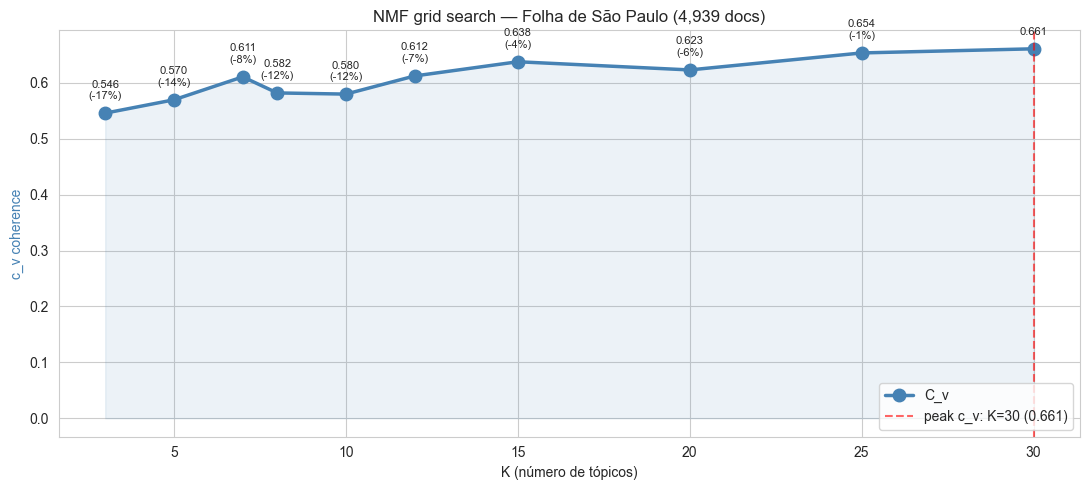


Peak: K=30 (c_v=0.6609)
K=10: c_v=0.5799 (delta vs peak: -12.3%)


In [9]:
# Cell 9 — Visualizacao c_v vs K
fig, ax = plt.subplots(figsize=(11, 5))
ks = sorted(scores)
vs = [scores[k] for k in ks]

ax.plot(ks, vs, marker="o", linewidth=2.5, markersize=9, color="steelblue", label="C_v")
ax.fill_between(ks, vs, alpha=0.1, color="steelblue")

peak_k = max(scores, key=scores.get)
ax.axvline(peak_k, color="red", linestyle="--", alpha=0.6, label=f"peak c_v: K={peak_k} ({scores[peak_k]:.3f})")

# Annotate each K
for k, v in zip(ks, vs):
    delta = (v - scores[peak_k]) / scores[peak_k] * 100
    label = f"{v:.3f}" if k == peak_k else f"{v:.3f}\n({delta:+.0f}%)"
    ax.annotate(label, (k, v), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=8)

ax.set_xlabel("K (número de tópicos)"); ax.set_ylabel("c_v coherence", color="steelblue")
ax.set_title(f"NMF grid search — Folha de São Paulo ({len(docs):,} docs)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(BASE_OUTPUT_DIR / "nmf_grid_k_cv.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {BASE_OUTPUT_DIR / 'nmf_grid_k_cv.png'}")
plt.show()

print(f"\nPeak: K={peak_k} (c_v={scores[peak_k]:.4f})")
if 10 in scores:
    print(f"K=10: c_v={scores[10]:.4f} (delta vs peak: {(scores[10]-scores[peak_k])/scores[peak_k]*100:+.1f}%)")


## 5. Inspeção qualitativa multi-K

Como `c_v` favorece K menor, precisamos olhar **os tópicos em si** para escolher K com critério metodológico (não só estatístico). Carregamos os tópicos de K=5, 7, 10, 15, 30 pré-computados em `nmf_multi_k_inspect.csv`, se disponível (execução prévia opcional — ver célula abaixo).


In [10]:
# Cell 10 — Multi-K topics side by side (opcional, requer nmf_multi_k_inspect.csv pre-computado)
multi_path = f"{out_dir}/nmf_multi_k_inspect.csv"
if os.path.exists(multi_path):
    multi = pd.read_csv(multi_path)
    for k_val in sorted(multi["k"].unique()):
        sub = multi[multi["k"] == k_val].sort_values("topic_id")
        print(f"=== K={k_val} ===")
        for _, row in sub.iterrows():
            kws = row["keywords"].split(", ")[:8]
            print(f"  T{int(row['topic_id']):2d}: {', '.join(kws)}")
        print()
else:
    print("nmf_multi_k_inspect.csv nao encontrado — pulando inspecao multi-K (opcional).")


nmf_multi_k_inspect.csv nao encontrado — pulando inspecao multi-K (opcional).


In [11]:
# Categorias canônicas da Folha para validação
if 'category' in df.columns:
    cat_dist = df['category'].value_counts()
    print('Distribuicao de categorias:')
    print(cat_dist.to_string())
else:
    print('Coluna category nao encontrada — pular validacao por categoria')


Distribuicao de categorias:
category
ilustrada           500
equilibrioesaude    499
poder               499
cotidiano           498
mercado             498
esporte             496
mundo               494
educacao            489
ciencia             484
ambiente            482


## 6. Decisão de K e treino final

**Trade-off:** `c_v` favorece K pequeno. Combine com inspeção qualitativa. Ajuste `BEST_K` na célula abaixo se necessário.


Faixa de K declarada para folha: [15,30] (4 de 10 pontos admissiveis)
BEST_K pelo protocolo (secao 1.6): 15  (NPMI +0.1162)
  criterio: pareto NPMI x Diversity, desempate menor K
  NOTA: por C_v o argmax na faixa seria K=30 (C_v 0.6609 vs 0.6377 em K=15).
  Divergencia entre eixos e informacao a reportar, nao erro. O NPMI decide.

  K      NPMI       C_v   admissivel
    3  +0.0649  0.5458       - 
    5  +0.0888  0.5697       - 
    7  +0.0974  0.6107       - 
    8  +0.0735  0.5820       - 
   10  +0.0779  0.5799       - 
   12  +0.0979  0.6124       - 
   15  +0.1162  0.6377      sim
   20  +0.0986  0.6231      sim
   25  +0.1187  0.6535      sim
   30  +0.1299  0.6609      sim
Cache em ..\data\output\folha\nmf/nmf_kappa_minprob_grid.csv nao bate com grid/K/corpus atuais, ou falta NPMI/Diversity/cobertura (protocolo secao 1.6) — recalculando (cache: kappas=[0.5, 1.0, 2.0, 3.0, 4.0], min_probs=[0.0, 0.01, 0.05], k=25, corpus=folha_20260628_185652 | atual: kappas=[0.5, 1.0, 2.0, 3.0, 

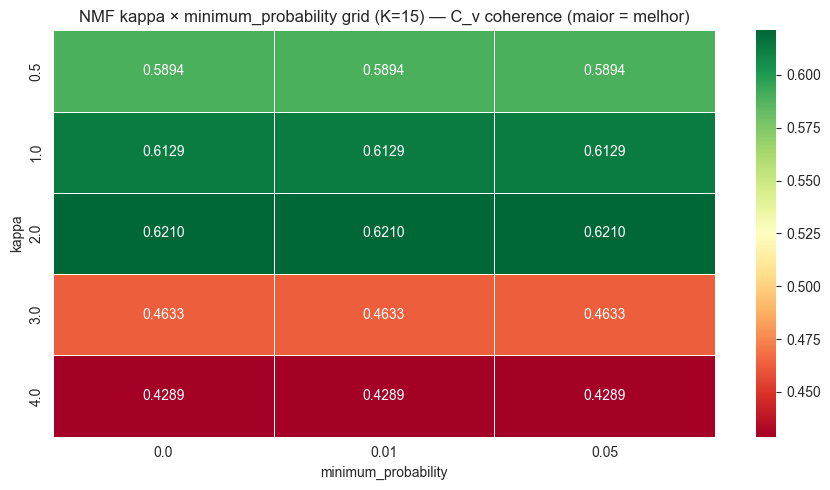


Treinando NMF K=15, kappa=1.0, minimum_probability=0.0, passes=20...
  done em 10s
Erro de reconstrucao (||V-WH||_F / ||V||_F, normalizado): 0.9309

Topics (top-10):
  T 0: ['país', 'brasil', 'pessoa', 'brasileiro', 'dose', 'acordo', 'vacina', 'população', 'mundo', 'vacinar']
  T 1: ['saúde', 'caso', 'dado', 'ministério', 'doença', 'paciente', 'morte', 'médico', 'pandemia', 'criança']
  T 2: ['pessoa', 'estudo', 'mulher', 'pesquisa', 'universidade', 'humano', 'pesquisador', 'vida', 'animal', 'paciente']
  T 3: ['governo', 'país', 'presidente', 'partido', 'trump', 'eua', 'americano', 'político', 'china', 'guerra']
  T 4: ['federal', 'caso', 'justiça', 'processo', 'decisão', 'público', 'tribunal', 'lula', 'polícia', 'ministro']
  T 5: ['paulo', 'pessoa', 'cidade', 'prefeitura', 'governador', 'região', 'paulista', 'doria', 'psdb', 'capital']
  T 6: ['trabalho', 'empresa', 'casa', 'pessoa', 'trabalhador', 'trabalhar', 'escritório', 'funcionário', 'híbrido', 'ficar']
  T 7: ['terra', 'miss

In [12]:
# Cell 12 — Grid kappa/minimum_probability (K=BEST_K fixo) + treino final
# PROTOCOLO 2026-08-16 (docs/protocolo-selecao-final-2026-08-16.md, secoes 4.1 e 4.2.2)
# ANTES: BEST_K = argmax(C_v) sobre a grade inteira. Mesma correcao do LDA (secao 4.2.1):
# o eixo de ordenacao do NMF passa a ser o NPMI, dentro da faixa DECLARADA de K (A3,
# fonte unica em _selecao.py) — sem a faixa, todo criterio testado desce para o
# extremo grosso da grade (protocolo secao 3.2, resultado 3).
from _selecao import FAIXA_K, _decidir_curva_k, _porta_cobertura_nmf, _pareto
_k_min, _k_max = FAIXA_K[CORPUS_ID]
_k_admissiveis = [k for k in npmi_scores if _k_min <= k <= _k_max]
if not _k_admissiveis:
    raise ValueError(
        f"nenhum K da grade {sorted(npmi_scores)} cai na faixa declarada "
        f"[{_k_min},{_k_max}] para {CORPUS_ID} — revise a grade ou a faixa, "
        f"mas declare a mudanca antes de olhar os resultados"
    )
_curvas_k = {"NPMI": npmi_scores, "Diversity": div_scores}
BEST_K, _criterio_k = _decidir_curva_k(_curvas_k, _k_min, _k_max)
if BEST_K is None:
    raise ValueError(f"_decidir_curva_k nao achou K admissivel: {_criterio_k}")
_best_k_cv = max(_k_admissiveis, key=lambda k: scores[k])

print(f"Faixa de K declarada para {CORPUS_ID}: [{_k_min},{_k_max}] "
      f"({len(_k_admissiveis)} de {len(npmi_scores)} pontos admissiveis)")
print(f"BEST_K pelo protocolo (secao 1.6): {BEST_K}  (NPMI {npmi_scores[BEST_K]:+.4f})")
print(f"  criterio: {_criterio_k}")
if "FORA do protocolo" in _criterio_k:
    print("  !! sem curva de Diversity no grid — decisao caiu para NPMI puro (fora do protocolo)")
if _best_k_cv != BEST_K:
    print(f"  NOTA: por C_v o argmax na faixa seria K={_best_k_cv} "
          f"(C_v {scores[_best_k_cv]:.4f} vs {scores[BEST_K]:.4f} em K={BEST_K}).")
    print("  Divergencia entre eixos e informacao a reportar, nao erro. O NPMI decide.")

# Curva completa — reportar a CURVA, nao so o argmax.
print("\n  K      NPMI       C_v   admissivel")
for _k in sorted(npmi_scores):
    _adm = "sim" if _k_min <= _k <= _k_max else " - "
    print(f"  {_k:>3d}  {npmi_scores[_k]:+.4f}  {scores[_k]:.4f}      {_adm}")

_khp_cache = f"{BASE_OUTPUT_DIR}/nmf_kappa_minprob_grid.csv"
_kappa_grid = params["evaluation"].get("nmf_kappa_grid", [0.5, 1.0, 2.0])
_min_prob_grid = params["evaluation"].get("nmf_min_prob_grid", [0.0, 0.01, 0.05])

# Cache so e reaproveitado se casar com grid/K/corpus atuais E trouxer as colunas
# que a decisao do protocolo (secao 1.6) exige — evita usar um grid desatualizado
# (ex.: kappa_grid estendido no params.yaml, ou grid anterior a NPMI/Diversity/cobertura,
# que ANTES da correcao de 2026-08-23 era o unico caso: score_by="cv" era o default e
# best_kappa/best_min_prob vinham direto do primeiro estagio sem porta nenhuma).
_khp_cache_valid = False
if os.path.exists(_khp_cache):
    khp_df = pd.read_csv(_khp_cache)
    _cached_kappas = sorted(khp_df["kappa"].unique().tolist()) if "kappa" in khp_df.columns else []
    _cached_min_probs = sorted(khp_df["minimum_probability"].unique().tolist()) if "minimum_probability" in khp_df.columns else []
    _cached_k = int(khp_df["k"].iloc[0]) if "k" in khp_df.columns and len(khp_df) else None
    _cached_corpus_version = khp_df["corpus_version"].iloc[0] if "corpus_version" in khp_df.columns and len(khp_df) else None
    _khp_tem_colunas = all(col in khp_df.columns for col in ("NPMI", "Diversity", "cobertura"))
    _khp_cache_valid = (
        _cached_kappas == sorted(_kappa_grid)
        and _cached_min_probs == sorted(_min_prob_grid)
        and _cached_k == BEST_K
        and _cached_corpus_version == CORPUS_VERSION
        and _khp_tem_colunas
    )
    if not _khp_cache_valid:
        print(f"Cache em {_khp_cache} nao bate com grid/K/corpus atuais, ou falta NPMI/Diversity/cobertura "
              f"(protocolo secao 1.6) — recalculando "
              f"(cache: kappas={_cached_kappas}, min_probs={_cached_min_probs}, k={_cached_k}, corpus={_cached_corpus_version} "
              f"| atual: kappas={sorted(_kappa_grid)}, min_probs={sorted(_min_prob_grid)}, k={BEST_K}, corpus=CORPUS_VERSION).")

if _khp_cache_valid:
    print(f"Grid kappa/minimum_probability carregado do cache ({_khp_cache}).")
else:
    print(f"Grid kappa ({len(_kappa_grid)}) × minimum_probability ({len(_min_prob_grid)}) = {len(_kappa_grid)*len(_min_prob_grid)} combos, passes=10...")
    t0 = time.time()
    khp_df, _best_kappa_grid, _best_min_prob_grid = grid_search_nmf_hparams(
        corpus_bow, dictionary, tokenized, BEST_K,
        kappa_grid=_kappa_grid, min_prob_grid=_min_prob_grid, seed=seed, passes=10,
        score_by="npmi",
        checkpoint_path=BASE_OUTPUT_DIR / "nmf_hparams_checkpoint.csv",
    )
    khp_df["k"] = BEST_K
    khp_df["corpus_version"] = CORPUS_VERSION
    khp_df.to_csv(_khp_cache, index=False)
    print(f"  done em {time.time()-t0:.0f}s")

print(khp_df.to_string(index=False))

# Decisao do protocolo (secao 1.6): porta de cobertura + Pareto NPMI x Diversity
# sobre a grade INTEIRA — best_kappa/best_min_prob de grid_search_nmf_hparams NAO e
# a decisao do protocolo (mesmo com score_by="npmi"): e so um sort escalar de
# conveniencia, e nao aplica a porta de cobertura. Mesma logica que
# _selecao.selecionar_nmf roda sobre o CSV em disco, aplicada aqui inline sobre o
# khp_df ja em memoria (evita reler o CSV que acabou de ser escrito).
_khp_filtrada, _nota_cobertura = _porta_cobertura_nmf(khp_df)
print(f"\n{_nota_cobertura}")
if _khp_filtrada.empty:
    raise ValueError("NENHUM ponto kappa/minimum_probability admissivel apos a porta de cobertura (secao 1.6)")
_khp_fronteira = _pareto(_khp_filtrada, ["NPMI", "Diversity"])
_khp_alvo = _khp_fronteira if not _khp_fronteira.empty else _khp_filtrada
_khp_escolhida = _khp_alvo.sort_values("NPMI", ascending=False).iloc[0]
best_kappa = float(_khp_escolhida["kappa"])
best_min_prob = float(_khp_escolhida["minimum_probability"])
print(f"\n  ★ best_kappa={best_kappa!r}  best_min_prob={best_min_prob!r}  "
      f"(NPMI {_khp_escolhida['NPMI']:+.4f}, cobertura {_khp_escolhida['cobertura']:.4f})")

# Heatmap C_v por kappa × minimum_probability
if len(khp_df) > 1:
    _pivot = khp_df.pivot_table(index="kappa", columns="minimum_probability", values="cv", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(9, max(3, len(_pivot) * 0.8 + 1)))
    sns.heatmap(_pivot, annot=True, fmt=".4f", cmap="RdYlGn", ax=ax, linewidths=0.5)
    ax.set_title(f"NMF kappa × minimum_probability grid (K={BEST_K}) — C_v coherence (maior = melhor)")
    plt.tight_layout(); plt.show()

# Treino final com melhores hiperparâmetros
print(f"\nTreinando NMF K={BEST_K}, kappa={best_kappa!r}, minimum_probability={best_min_prob!r}, passes=20...")
t0 = time.time()
model = train_nmf(corpus_bow, dictionary, k=BEST_K, seed=seed, passes=20, kappa=best_kappa, minimum_probability=best_min_prob)
print(f"  done em {time.time()-t0:.0f}s")

# C4 (protocolo, secao 4.2.2): erro de reconstrucao de Frobenius — analogo da
# perplexidade do LDA, que o gensim.models.Nmf nao expoe.
reconstruction_error = compute_nmf_reconstruction_error(model, corpus_bow)
print(f"Erro de reconstrucao (||V-WH||_F / ||V||_F, normalizado): {reconstruction_error:.4f}")

top_n = params["evaluation"]["top_n_keywords"]
topics_keywords = extract_topics_keywords(model, k=BEST_K, top_n=top_n)

print(f"\nTopics (top-{top_n}):")
for tid in sorted(topics_keywords):
    print(f"  T{tid:2d}: {topics_keywords[tid]}")


Salvo: ..\data\output\folha\nmf\nmf_grid_kappa_minprob_heatmap.png


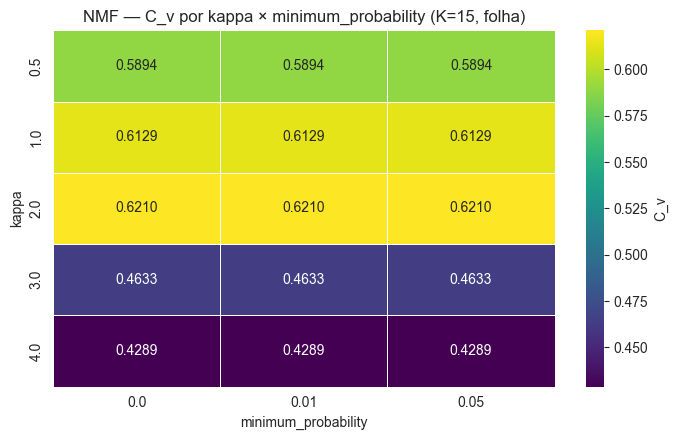

In [13]:
# Heatmap C_v do grid kappa x minimum_probability (le o cache do diretorio-base)
_khp_csv = BASE_OUTPUT_DIR / "nmf_kappa_minprob_grid.csv"
if _khp_csv.exists():
    _g = pd.read_csv(_khp_csv)
    _piv = _g.pivot_table(index="kappa", columns="minimum_probability", values="cv")
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.heatmap(_piv, annot=True, fmt=".4f", cmap="viridis", linewidths=0.5, ax=ax,
                cbar_kws={"label": "C_v"})
    ax.set_title(f"NMF — C_v por kappa × minimum_probability (K={BEST_K}, {CORPUS_ID})")
    plt.tight_layout()
    plt.savefig(BASE_OUTPUT_DIR / "nmf_grid_kappa_minprob_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Salvo: {BASE_OUTPUT_DIR / 'nmf_grid_kappa_minprob_heatmap.png'}")
    plt.show()
else:
    print("Sem nmf_kappa_minprob_grid.csv — heatmap pulado")

## 7. Rotulagem via LLM (Ollama)

`_helpers.name_all_topics` envia as keywords pro modelo configurado em `params.yaml` (`llm.model`) via Ollama com prompt few-shot em PT-BR. Em ~9s/tópico em CPU. Fallback: top-3 keywords se Ollama indisponível.


In [14]:
# === Nomeação NMF via LLM — pipeline melhorado ===
#
# Melhorias vs naming genérico anterior:
# - top_n_keywords_llm=50 (params.yaml; antes só 10 keywords passavam)
# - 3 docs representativos por probabilidade theta (antes: 0 docs)
# - Prompt PT-BR few-shot + anti-redundância + regra TEMA GERAL
# - Deduplicação pós-geração
# - Ordering por tamanho (maiores tópicos primeiro → nomes centrais primeiro)
# - /no_think removido (diretiva Qwen3; gemma2:2b ignora ou ecoa como texto)

llm_cfg = params.get("llm", {})
top_n_llm = params["evaluation"].get("top_n_keywords_llm", 50)

# ---- Extrai até top_n_llm keywords por tópico para o LLM ----
topics_keywords_llm = {
    tid: [w for w, _ in model.show_topic(tid, topn=top_n_llm)]
    for tid in range(BEST_K)
}

# ---- Docs representativos: 3 docs com maior probabilidade theta ----
# Computa distribuições inline se ainda não foram computadas
if "theta_arr" not in dir() or "dominant" not in dir():
    print("  theta_arr ausente — computando doc distributions inline...")
    _dom_tmp, _full_tmp = compute_doc_distributions(model, corpus_bow, k=BEST_K)
    theta_arr = np.array(_full_tmp)
    dominant = list(_dom_tmp)

N_REPR_DOCS_NMF = 3

def _representative_docs_nmf(tid, n=N_REPR_DOCS_NMF):
    """3 docs com maior P(tópico|doc) para o tópico tid."""
    top_idx = np.argsort(theta_arr[:, tid])[::-1][:n]
    return [docs[i] for i in top_idx]

# ---- Prompt PT-BR com few-shot + anti-redundância ----
_FEW_SHOT_NMF = """\
Exemplos de bom rótulo (frase nominal coerente):

  Palavras-chave: eleição, presidente, voto, urna, candidato, campanha
  Rótulo: Eleições presidenciais e campanha

  Palavras-chave: selic, juros, banco central, inflação, copom, mercado
  Rótulo: Política monetária e controle da inflação

  Palavras-chave: futebol, campeonato, time, jogador, gol, brasileirão
  Rótulo: Futebol e campeonato nacional

  Palavras-chave: stf, supremo, ministro, julgamento, lei, constituição
  Rótulo: Decisões do Supremo Tribunal Federal

  Palavras-chave: clima, chuva, temperatura, seca, enchente, alerta
  Rótulo: Eventos climáticos extremos no Brasil

  Palavras-chave: cinema, filme, série, streaming, roteiro, diretor
  Rótulo: Cinema, séries e produções audiovisuais

Exemplos de DOIS temas PRÓXIMOS nomeados de forma DISTINTA (faça assim):

  Palavras-chave: clima, emissões, energia, países, combustíveis, acordo
  Rótulo: Política climática e transição energética

  Palavras-chave: gelo, antártida, temperaturas, el niño, calor, degelo
  Rótulo: Aquecimento global e degelo polar

Exemplo de rótulo RUIM (NÃO faça assim):
  - "eleição, presidente, voto" (é LISTA de keywords, não rótulo)
"""


def _prompt_builder_nmf(keywords, example_docs=None, assigned_names=None):
    keywords_str = ", ".join(keywords[:top_n_llm])
    avoid_block = ""
    if assigned_names:
        _listed = "\n".join(f"- {n}" for n in assigned_names)
        avoid_block = (
            "\nRÓTULOS já atribuídos (NÃO repita nem faça variação leve):\n"
            + _listed + "\n"
            "Se este tópico for parecido com algum acima, identifique o termo das "
            "palavras-chave que o DIFERENCIA e use-o no rótulo. NUNCA use sufixos "
            "como '(2)' ou '(gelo)'.\n\n"
        )
    docs_block = ""
    if example_docs:
        snippets = [
            f"[Documento {i + 1}]\n{d[:250].strip()}..."
            for i, d in enumerate(example_docs[:3])
        ]
        docs_block = "\n\nDocumentos representativos do tópico:\n" + "\n\n".join(snippets)
    return (
        "Você é um especialista em análise temática de notícias brasileiras.\n"
        "Crie um RÓTULO HUMANO LEGÍVEL (frase nominal PT-BR, 4-6 palavras).\n\n"
        + _FEW_SHOT_NMF + "\n" + avoid_block
        + "Agora nomeie este tópico:\n\n"
        f"Palavras-chave: {keywords_str}{docs_block}\n\n"
        "Regras:\n"
        "- Uma única frase nominal coerente (4-6 palavras).\n"
        "- As PRIMEIRAS palavras-chave são as mais importantes (maior peso): baseie o rótulo nelas.\n"
        "- Se as palavras misturarem dois assuntos, nomeie o ASSUNTO DOMINANTE (o das primeiras palavras), não uma mistura vaga.\n"
        "- Nomeie o TEMA GERAL comum aos documentos, não um evento isolado.\n"
        "- Rótulo CLARAMENTE DISTINTO dos já listados (use o termo que diferencia este tópico).\n"
        "- Sem aspas, sem prefixo 'Rótulo:', sem explicações.\n"
        "- Capitalize apenas a primeira palavra.\n\nRótulo:"
    )


_system_prompt_nmf = (
    "Você é um especialista em análise temática de notícias brasileiras. "
    "Responda SEMPRE em português brasileiro com uma frase nominal curta (4-6 palavras). "
    "NUNCA use listas de palavras-chave separadas por vírgula."
)


def _dedupe_name_nmf(name, keywords, used_lower):
    """Garante unicidade: keyword distintiva ou sufixo numérico."""
    if name.lower() not in used_lower:
        return name
    for kw in keywords:
        if kw.lower() not in name.lower():
            cand = f"{name} ({kw})"
            if cand.lower() not in used_lower:
                return cand
    i = 2
    while f"{name} ({i})".lower() in used_lower:
        i += 1
    return f"{name} ({i})"


# ---- Ordering por tamanho do tópico ----
_topic_counts_nmf = pd.Series(dominant).value_counts().to_dict()
_order_nmf = sorted(range(BEST_K), key=lambda t: -_topic_counts_nmf.get(t, 0))

_used_lower_nmf: set = set()
_assigned_names_nmf: list = []
names: dict = {}

naming_enabled = llm_cfg.get("enabled", True)
if naming_enabled:
    print(f"Nomeando {BEST_K} tópicos NMF via LLM ({llm_cfg['model']})...")
    print(f"  top_n_llm={top_n_llm} | {N_REPR_DOCS_NMF} docs por theta | anti-redundância: ativo | ordem: maior → menor\n")
    for tid in _order_nmf:
        kws = topics_keywords_llm[tid]
        rep_docs = _representative_docs_nmf(tid)

        def _pb(keywords, example_docs=None, _an=list(_assigned_names_nmf)):
            return _prompt_builder_nmf(keywords, example_docs, assigned_names=_an)

        t0 = time.time()
        name = name_topic(
            kws,
            model=llm_cfg["model"],
            base_url=llm_cfg.get("base_url", "http://localhost:11434"),
            example_docs=rep_docs,
            prompt_builder=_pb,
            system_prompt=_system_prompt_nmf,
        )
        name = _dedupe_name_nmf(name, kws, _used_lower_nmf)
        _used_lower_nmf.add(name.lower())
        _assigned_names_nmf.append(name)
        names[tid] = name

        top3 = ", ".join(kws[:3])
        print(f"  T{tid:>2} ({_topic_counts_nmf.get(tid, 0):>4} docs, {time.time() - t0:.1f}s): {name}")
        print(f"       [{top3}]")
else:
    print("LLM desabilitado — usando fallback top-3 keywords.")
    names = {tid: ", ".join(kws[:3]) for tid, kws in topics_keywords.items()}

names = {t: names.get(t, f"T{t}") for t in range(BEST_K)}
print(f"\n{BEST_K} tópicos nomeados.")


  theta_arr ausente — computando doc distributions inline...
Nomeando 15 tópicos NMF via LLM (gemma2:2b-instruct-q4_K_M)...
  top_n_llm=50 | 3 docs por theta | anti-redundância: ativo | ordem: maior → menor

  T 2 ( 845 docs, 7.8s): Ciência e Biologia Humana
       [pessoa, estudo, mulher]
  T11 ( 595 docs, 2.9s): Futebol e Copa do Mundo no Brasil
       [brasil, brasileiro, sportv]
  T 4 ( 513 docs, 2.9s): Operação Lava Jato e justiça pública
       [federal, caso, justiça]
  T 3 ( 512 docs, 2.8s): Guerra e Política Internacional
       [governo, país, presidente]
  T12 ( 397 docs, 2.9s): Aquecimento global e mudanças climáticas
       [água, climático, região]
  T 5 ( 363 docs, 2.9s): Políticas Públicas no Estado de São Paulo
       [paulo, pessoa, cidade]
  T14 ( 327 docs, 2.8s): Política educacional e governo
       [governo, educação, ministro]
  T10 ( 236 docs, 2.9s): Educação e ensino médio no Brasil
       [escola, aluno, ensino]
  T 1 ( 219 docs, 2.8s): Saúde pública e pandemi

## 8. Visualização dos tópicos

Wordclouds + bar charts mostram a estrutura semântica de cada tópico. Escala logarítmica destaca palavras menos frequentes mas igualmente representativas.


Salvo: ..\data\output\folha\nmf\folha_20260824_183512\nmf_wordclouds.png


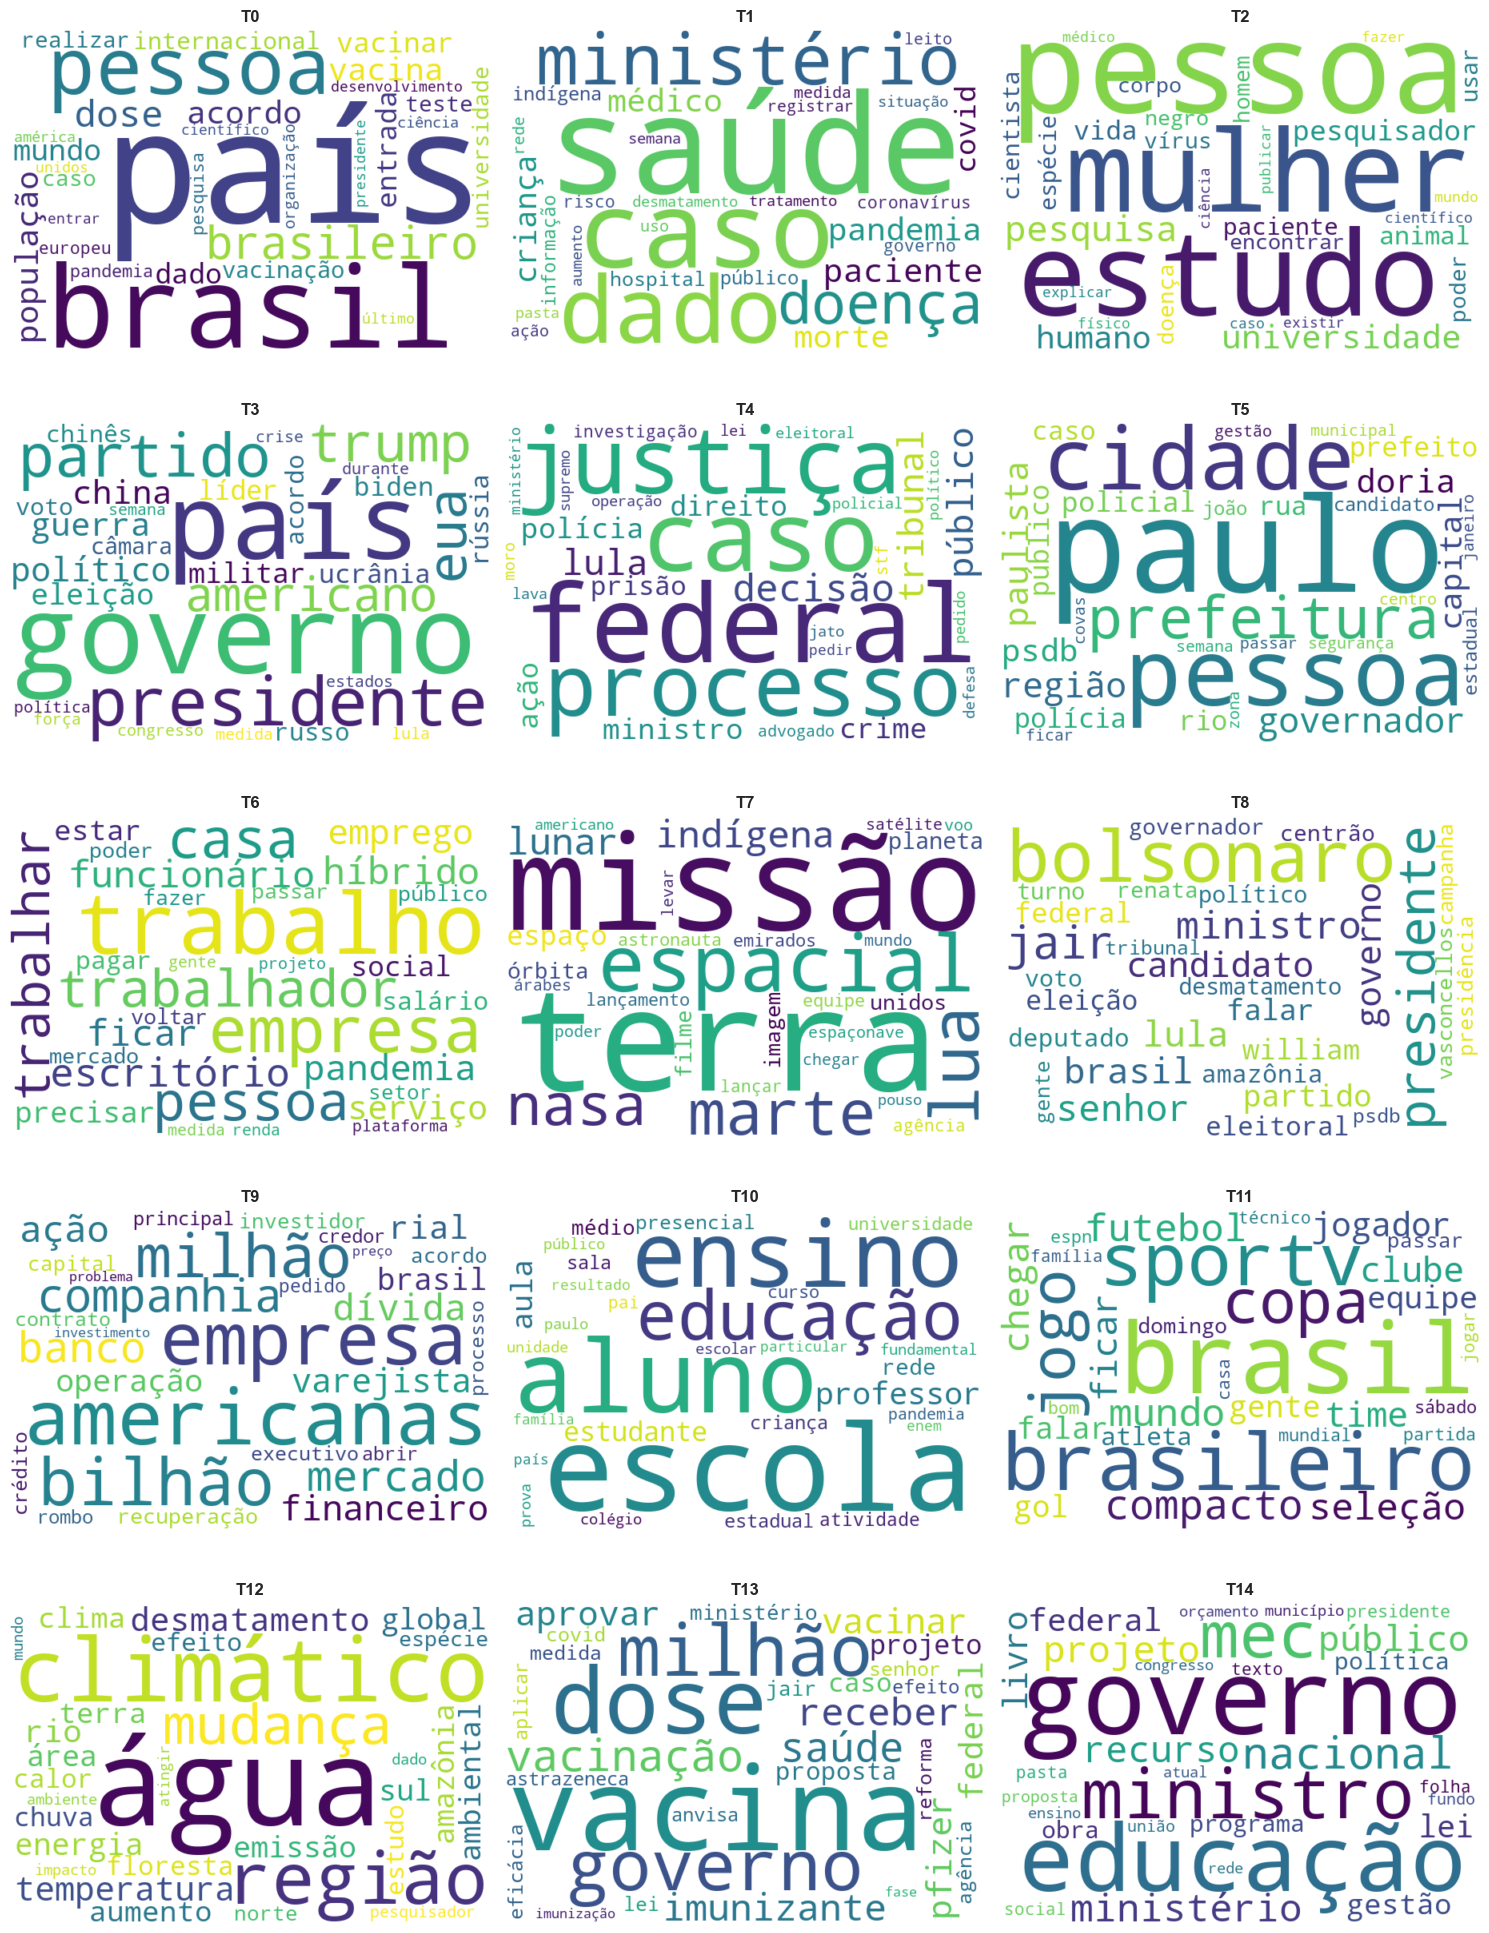

In [15]:
# Cell 13 — Wordclouds (1 por topico)
ncols = 3
nrows = (BEST_K + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

_dead_topics = []
for tid in sorted(topics_keywords):
    # gensim show_topic retorna (palavra, prob); usar prob como freq do wordcloud
    word_probs = dict(model.show_topic(tid, topn=30))
    # topico "morto" (sem massa de probabilidade, comum com K alto): show_topic
    # pode retornar NaN quando a linha normaliza 0/0
    valid_probs = {w: p for w, p in word_probs.items() if np.isfinite(p) and p > 0}
    axes[tid].set_title(f"T{tid}", fontsize=12, fontweight="bold")
    axes[tid].axis("off")
    if not valid_probs:
        _dead_topics.append(tid)
        axes[tid].text(0.5, 0.5, "topico degenerado\n(sem massa de probabilidade)",
                       ha="center", va="center", fontsize=9, color="gray", wrap=True)
        continue
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap="viridis", max_words=30, prefer_horizontal=0.9).generate_from_frequencies(valid_probs)
    axes[tid].imshow(wc, interpolation="bilinear")

# Esconde axes nao usados
for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_wordclouds.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'nmf_wordclouds.png'}")
plt.show()

if _dead_topics:
    print(f"AVISO: {len(_dead_topics)} topico(s) degenerado(s) (sem massa de probabilidade): {_dead_topics}")
    print("  Indica K provavelmente alto demais para o vocabulario deste corpus — considere revisar BEST_K.")


Salvo: ..\data\output\folha\nmf\folha_20260824_183512\nmf_keywords_barchart.png


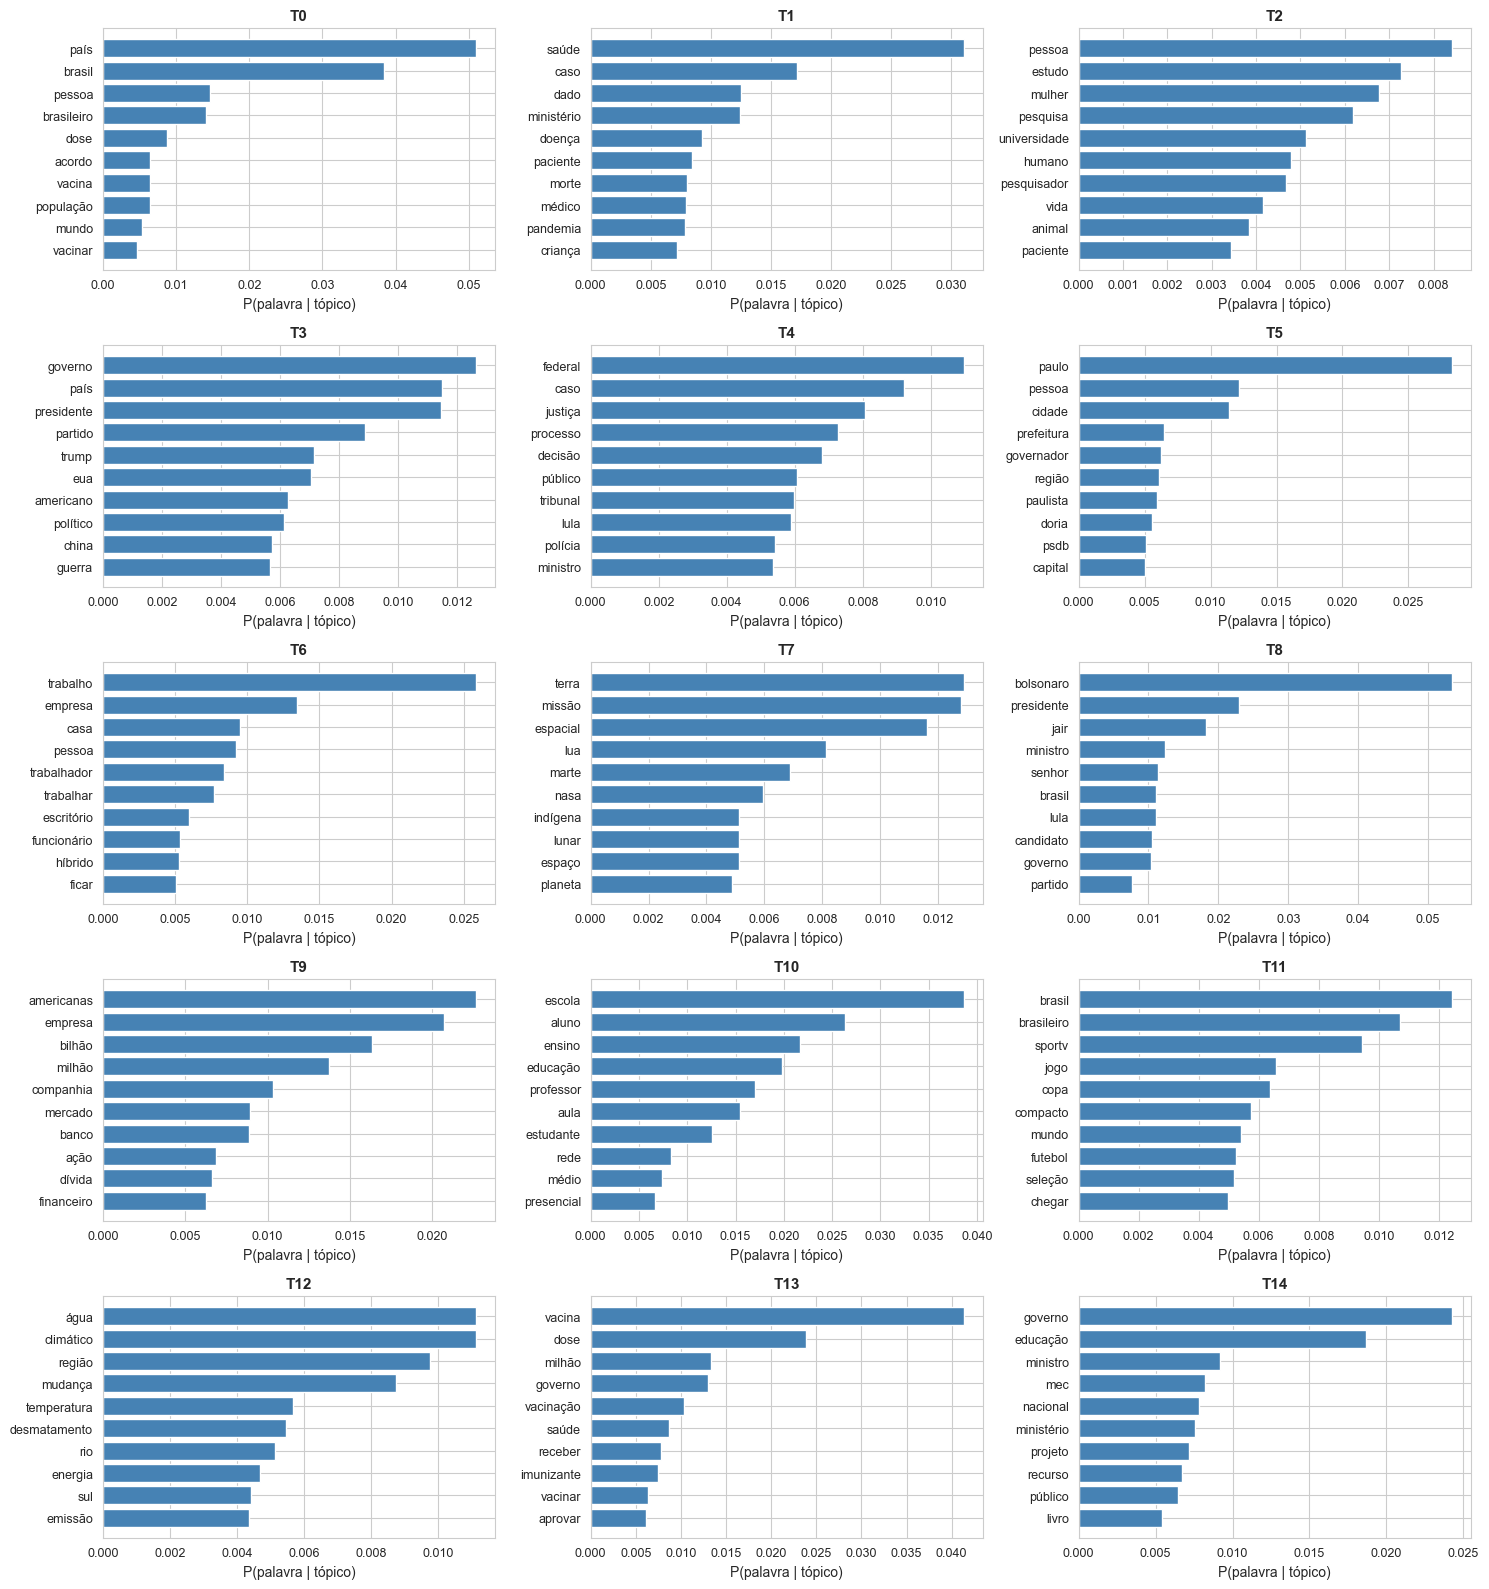

In [16]:
# Cell 14 — Bar chart top-10 keywords per topic
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

for tid in sorted(topics_keywords):
    word_probs = model.show_topic(tid, topn=10)
    words, probs = zip(*word_probs)
    axes[tid].barh(list(words)[::-1], list(probs)[::-1], color="steelblue")
    axes[tid].set_title(f"T{tid}", fontsize=11, fontweight="bold")
    axes[tid].set_xlabel("P(palavra | tópico)")
    axes[tid].tick_params(labelsize=9)

for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_keywords_barchart.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'nmf_keywords_barchart.png'}")
plt.show()


## Similaridade e redundância entre tópicos

O NMF não penaliza sobreposição de vocabulário entre tópicos (ao contrário do
LDA, que tem prior Dirichlet). Dois diagnósticos visuais:

- **Similaridade cosseno** entre as linhas de `φ` (tópico×vocabulário) — pares
  com similaridade alta são candidatos a merge ou a K menor.
- **Termite plot** — peso de cada termo (união dos top termos) em cada tópico,
  num único quadro.

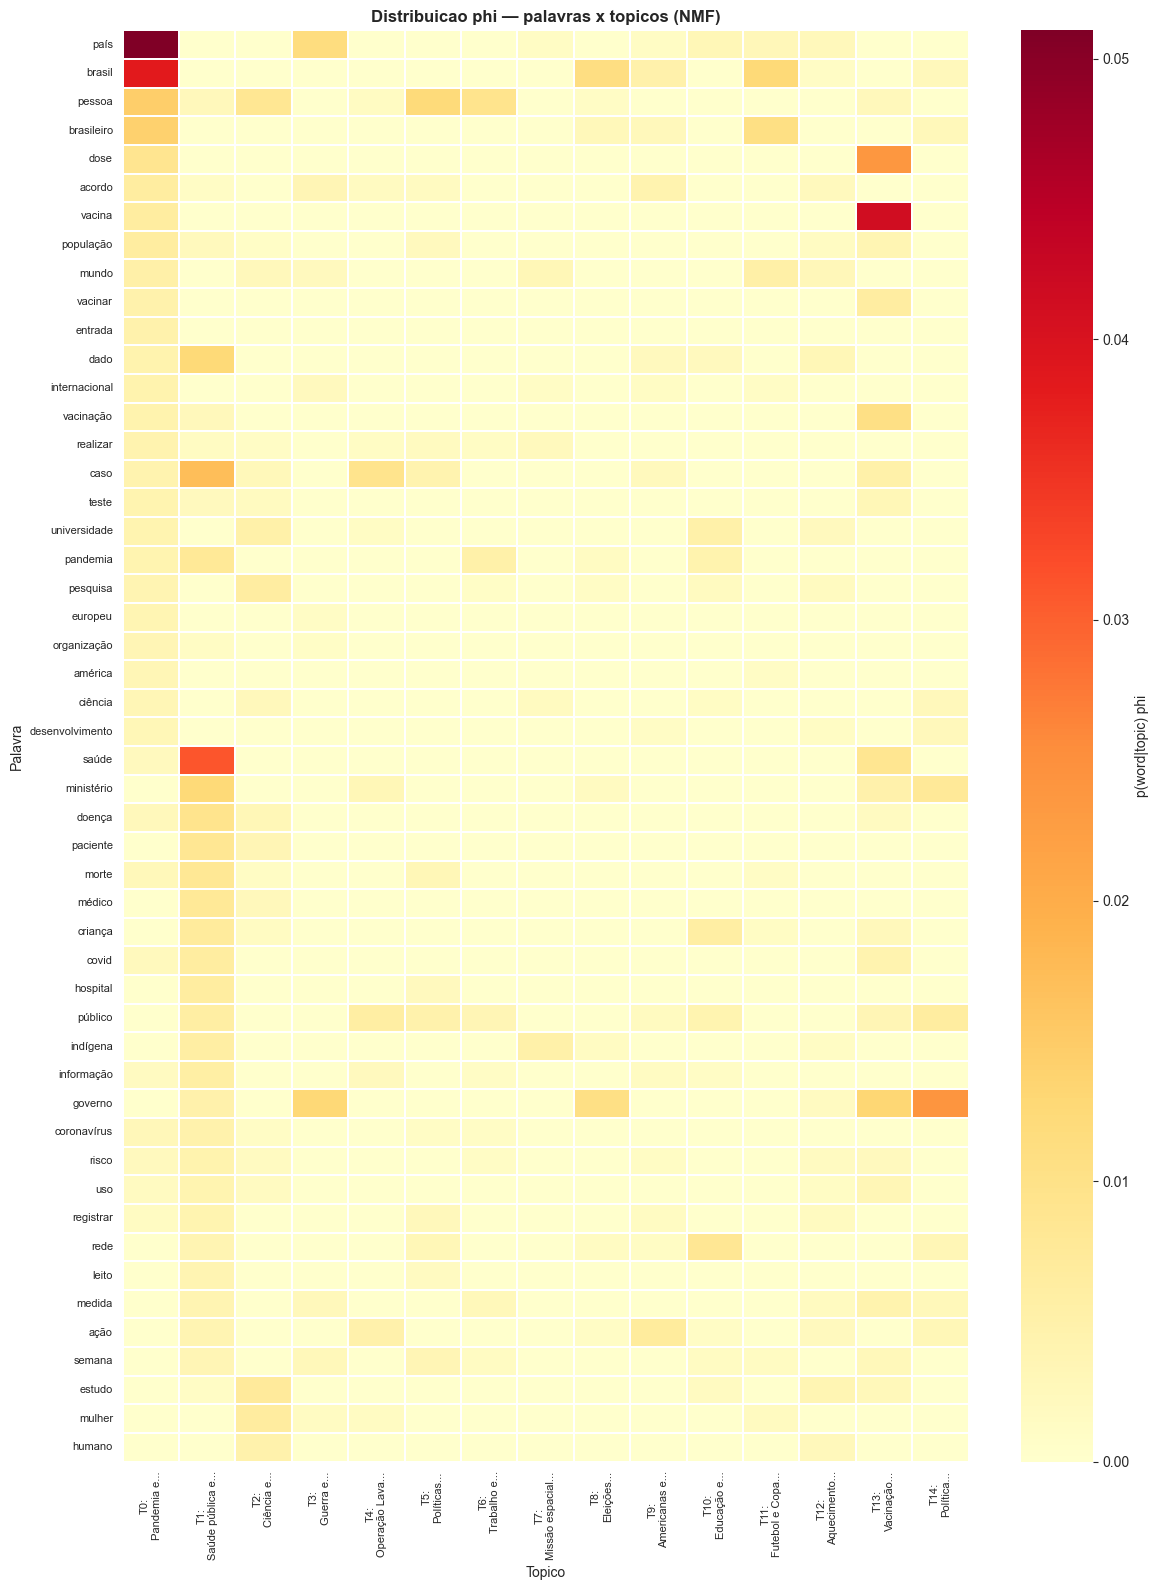

Salvo: ..\data\output\folha\nmf\folha_20260824_183512\nmf_heatmap_phi.png


In [17]:
# Heatmap phi: top palavras x topicos (mesmo formato do LDA — 02_lda_folha.ipynb)
import seaborn as sns
_top_n_phi = 25
_all_words = []
for tid in range(BEST_K):
    for w, _ in model.show_topic(tid, topn=_top_n_phi):
        if w not in _all_words:
            _all_words.append(w)
_all_words = _all_words[:min(50, len(_all_words))]

_phi_hm = np.zeros((len(_all_words), BEST_K))
for tid in range(BEST_K):
    _td = dict(model.show_topic(tid, topn=200))
    for wi, w in enumerate(_all_words):
        _phi_hm[wi, tid] = _td.get(w, 0.0)

import textwrap as _tw_phi
_col_labels = [f"T{t}:\n{_tw_phi.shorten(str(names.get(t, '')), 18, placeholder='...')}" for t in range(BEST_K)]
_phi_hm_df = pd.DataFrame(_phi_hm, index=_all_words, columns=_col_labels)

fig, ax = plt.subplots(figsize=(max(10, BEST_K * 0.8), max(8, len(_all_words) * 0.32)))
sns.heatmap(_phi_hm_df, cmap="YlOrRd", ax=ax, linewidths=0.15,
            cbar_kws={"label": "p(word|topic) phi"})
ax.set_title("Distribuicao phi — palavras x topicos (NMF)", fontsize=12, fontweight="bold")
ax.set_xlabel("Topico"); ax.set_ylabel("Palavra")
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_heatmap_phi.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'nmf_heatmap_phi.png'}")

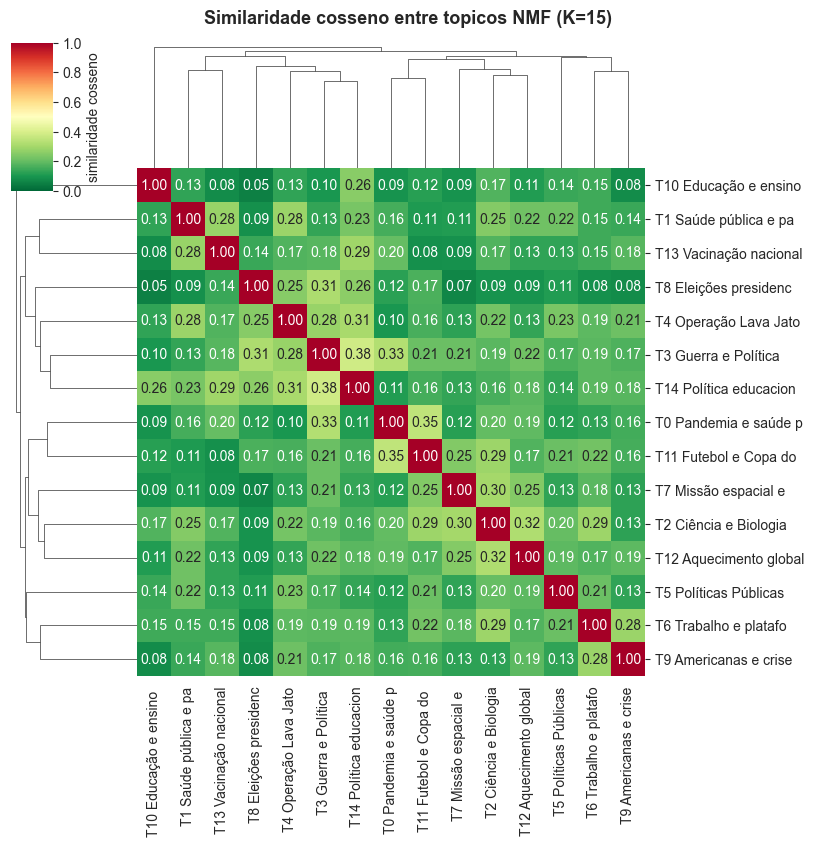

Top 5 pares de topicos mais similares (candidatos a redundancia):
  T3 <-> T14: cos=0.380  [Guerra e Política Internaciona | Política educacional e governo]
  T0 <-> T11: cos=0.349  [Pandemia e saúde pública no Br | Futebol e Copa do Mundo no Bra]
  T0 <-> T3: cos=0.325  [Pandemia e saúde pública no Br | Guerra e Política Internaciona]
  T2 <-> T12: cos=0.318  [Ciência e Biologia Humana | Aquecimento global e mudanças ]
  T3 <-> T8: cos=0.313  [Guerra e Política Internaciona | Eleições presidenciais brasile]


In [18]:
# Similaridade cosseno entre topicos (candidatos a redundancia/merge)
from scipy.spatial.distance import squareform, pdist

_phi_sim = model.get_topics()  # (K, vocab_size)
_sim = 1 - squareform(pdist(_phi_sim, metric="cosine"))
_sim_labels = [f"T{tid} {names[tid][:18]}" for tid in range(BEST_K)]
_sim_df = pd.DataFrame(_sim, index=_sim_labels, columns=_sim_labels)

g = sns.clustermap(_sim_df, cmap="RdYlGn_r", vmin=0, vmax=1,
                    figsize=(max(8, BEST_K * 0.55), max(8, BEST_K * 0.55)),
                    annot=BEST_K <= 15, fmt=".2f", cbar_kws={"label": "similaridade cosseno"})
g.fig.suptitle(f"Similaridade cosseno entre topicos NMF (K={BEST_K})", y=1.02, fontsize=13, fontweight="bold")
g.savefig(OUTPUT_DIR / "nmf_topic_similarity.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

_iu = np.triu_indices_from(_sim, k=1)
_pairs = sorted(zip(_sim[_iu], zip(_iu[0], _iu[1])), reverse=True)[:5]
print("Top 5 pares de topicos mais similares (candidatos a redundancia):")
for score, (i, j) in _pairs:
    print(f"  T{i} <-> T{j}: cos={score:.3f}  [{names[i][:30]} | {names[j][:30]}]")

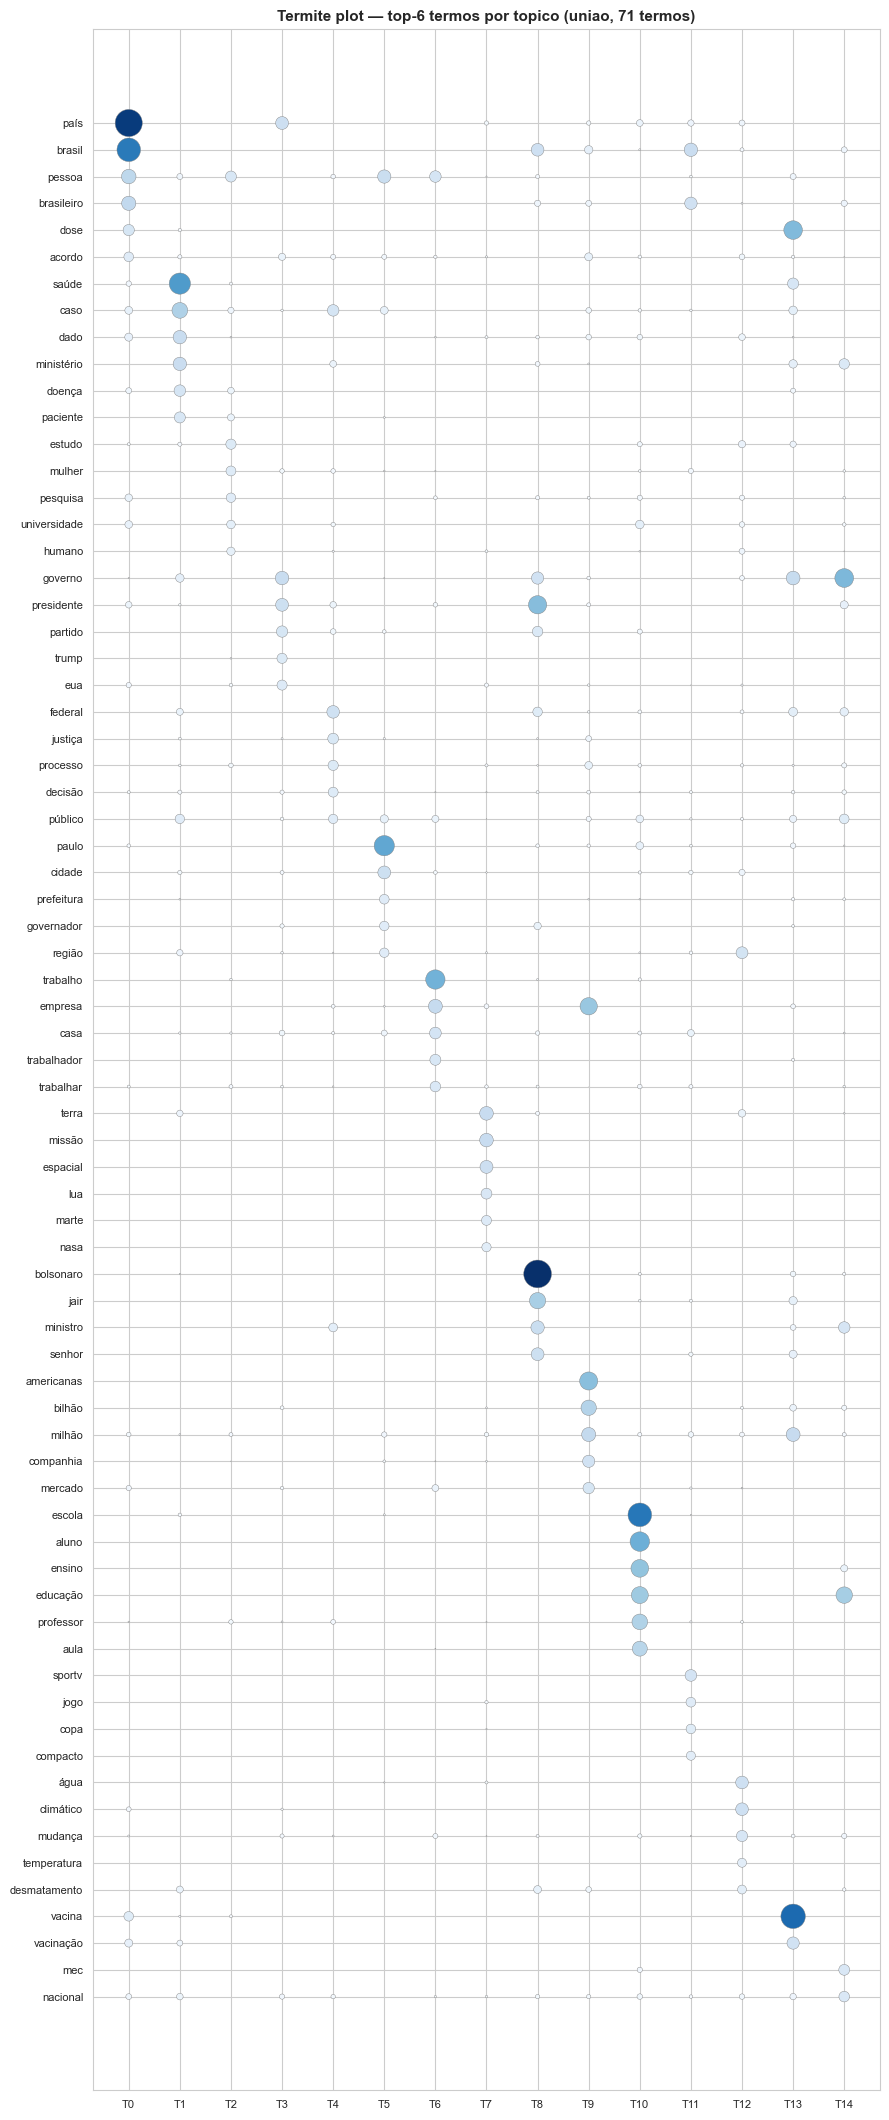

In [19]:
# Termite plot: peso topico x termo (uniao dos top termos por topico)
_TERMITE_TOPN = 6
_term_union, _seen_terms = [], set()
for tid in sorted(topics_keywords):
    for w in topics_keywords[tid][:_TERMITE_TOPN]:
        if w not in _seen_terms:
            _seen_terms.add(w)
            _term_union.append(w)

_phi_term = model.get_topics()  # (K, vocab_size)
_vocab_idx_term = {dictionary[i]: i for i in range(len(dictionary))}
_termite = pd.DataFrame(
    {f"T{tid}": [_phi_term[tid, _vocab_idx_term[w]] if w in _vocab_idx_term else 0.0 for w in _term_union]
     for tid in range(BEST_K)},
    index=_term_union,
)

fig, ax = plt.subplots(figsize=(max(8, BEST_K * 0.6), max(6, len(_term_union) * 0.3)))
_xx, _yy = np.meshgrid(range(BEST_K), range(len(_term_union)))
_sizes = _termite.values / _termite.values.max() * 400
ax.scatter(_xx.flatten(), _yy.flatten(), s=_sizes.flatten(), c=_sizes.flatten(),
           cmap="Blues", edgecolors="gray", linewidths=0.3)
ax.set_xticks(range(BEST_K)); ax.set_xticklabels([f"T{t}" for t in range(BEST_K)], fontsize=8)
ax.set_yticks(range(len(_term_union))); ax.set_yticklabels(_term_union, fontsize=8)
ax.set_title(f"Termite plot — top-{_TERMITE_TOPN} termos por topico (uniao, {len(_term_union)} termos)",
             fontsize=11, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 9. Métricas quantitativas

- **c_v** recomputada (validação cruzada do grid)
- **Exclusivity**: 1 - prop. de keywords compartilhadas entre tópicos
- **Topic Diversity**: razão de palavras únicas no consolidado dos top-K
- **Diversity entropy** das distribuições θ doc-tópico (quão espalhadas)


Calculando métricas...


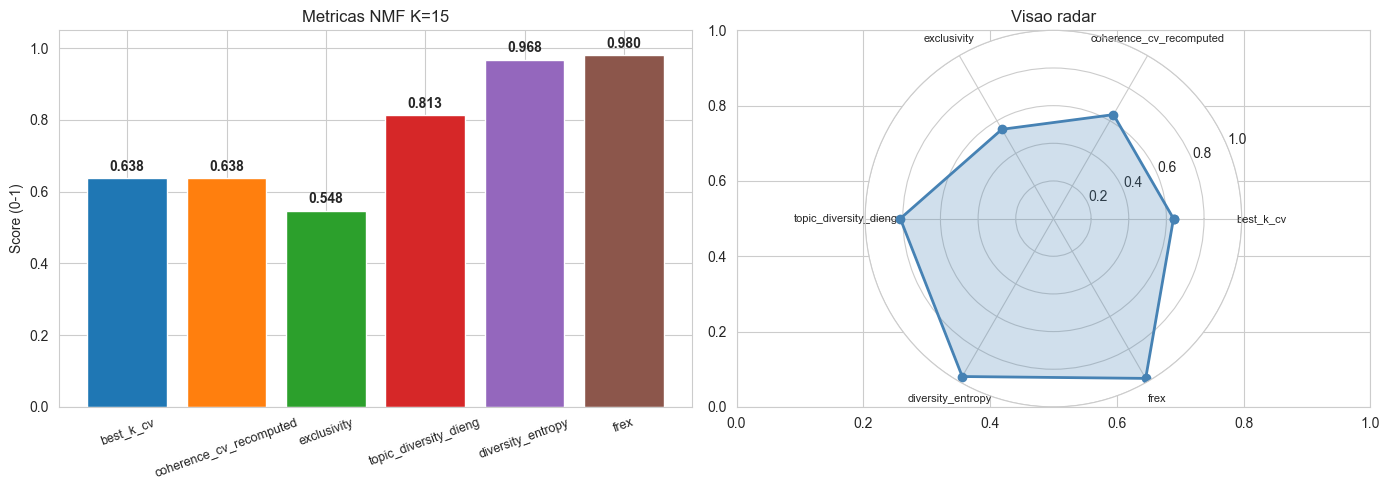

{
  "model": "nmf",
  "topic_type": "probabilistic",
  "granularity": "unit",
  "corpus": "folha",
  "corpus_version": "folha_20260628_185652",
  "n_topics": 15,
  "best_k_cv": 0.6377488190455628,
  "exclusivity": 0.5476199874064206,
  "diversity_entropy": 0.9684066682360184,
  "topic_diversity_dieng": 0.8133333333333334,
  "frex": 0.9798822631526032,
  "coherence_cv_recomputed": 0.6377488190455628
}


In [20]:
# Cell 16 — Calcula metricas
print("Calculando métricas...")
if "theta_arr" in dir() and "dominant" in dir():
    # Reaproveita a distribuição doc-tópico já computada na nomeação (célula
    # anterior) em vez de rodar get_document_topics() de novo sobre o corpus
    # inteiro.
    full = theta_arr.tolist()
else:
    dominant, full = compute_doc_distributions(model, corpus_bow, k=BEST_K)

# FREX — matriz de topicos do gensim (K x vocab_size); Nmf tambem expõe get_topics()
_phi = model.get_topics()  # shape (BEST_K, vocab_size)
_vocab_idx = {dictionary[i]: i for i in range(len(dictionary))}
_topic_idx = {tid: tid for tid in range(BEST_K)}
_top_n_metrics = params["evaluation"].get("top_n_keywords_metrics", 20)
frex_mean, frex_per_topic = compute_frex_score(
    topics_keywords, _phi, _vocab_idx, _topic_idx, top_n=_top_n_metrics,
)

# Exclusividade c-TF-IDF (MESMA metrica do LDA/BERTopic) - scores da matriz de topicos completa
_topic_word_scores_nmf = {
    tid: {dictionary[i]: float(_phi[tid, i]) for i in range(_phi.shape[1]) if _phi[tid, i] > 0}
    for tid in range(BEST_K)
}
_excl_mean, _excl_per_topic = compute_exclusivity_ctfidf(
    topics_keywords, _topic_word_scores_nmf, top_n=_top_n_metrics,
)

metrics = {
    "model": "nmf",
    "topic_type": "probabilistic",
    "granularity": "unit",
    "corpus": CORPUS_ID,
    "corpus_version": globals().get("CORPUS_VERSION", "n/a"),
    "n_topics": BEST_K,
    "best_k_cv": float(scores.get(BEST_K, 0.0)),
    "exclusivity": float(_excl_mean),
    "diversity_entropy": float(compute_diversity(full)),
    "topic_diversity_dieng": float(compute_topic_diversity(topics_keywords)),
    "frex": float(frex_mean),
}
metrics["coherence_cv_recomputed"] = float(compute_coherence_cv(topics_keywords, tokenized, dictionary))

# Visualiza num radar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
metric_keys = ["best_k_cv", "coherence_cv_recomputed", "exclusivity",
               "topic_diversity_dieng", "diversity_entropy", "frex"]
metric_vals = [metrics[k] for k in metric_keys]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
axes[0].bar(metric_keys, metric_vals, color=colors)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Score (0-1)")
axes[0].set_title(f"Metricas NMF K={BEST_K}")
axes[0].tick_params(axis="x", rotation=20, labelsize=9)
for i, (k, v) in enumerate(zip(metric_keys, metric_vals)):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

# Radar
angles = np.linspace(0, 2*np.pi, len(metric_keys), endpoint=False).tolist()
vals = metric_vals + [metric_vals[0]]
angles_p = angles + [angles[0]]
axes[1] = plt.subplot(122, projection="polar")
axes[1].plot(angles_p, vals, "o-", linewidth=2, color="steelblue")
axes[1].fill(angles_p, vals, alpha=0.25, color="steelblue")
axes[1].set_xticks(angles); axes[1].set_xticklabels(metric_keys, fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_title("Visao radar")

plt.tight_layout(); plt.show()
print(json.dumps(metrics, indent=2))

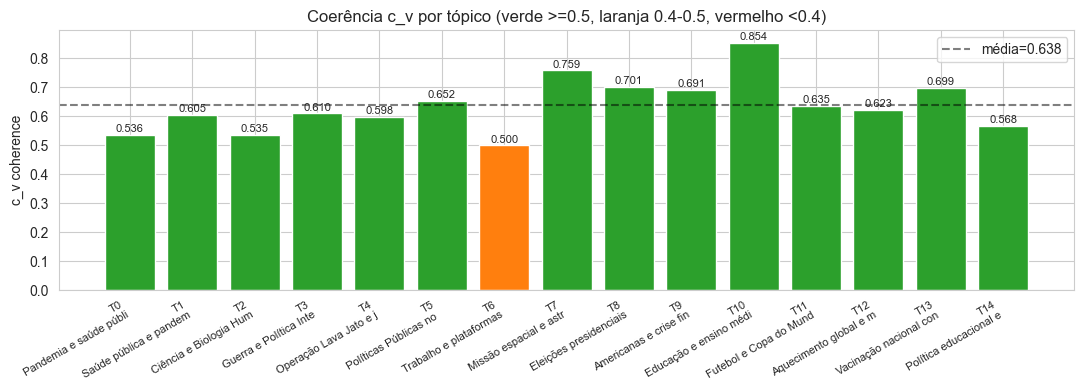

In [21]:
# Cell 17 — c_v por topico (nao so media)
from gensim.models import CoherenceModel
cm = CoherenceModel(
    topics=[topics_keywords[tid] for tid in sorted(topics_keywords)],
    texts=tokenized, dictionary=dictionary, coherence="c_v",
)
per_topic_cv = cm.get_coherence_per_topic()

fig, ax = plt.subplots(figsize=(11, 4))
tids = sorted(topics_keywords)
labels = [f"T{tid}\n{names[tid][:22]}" for tid in tids]
bars = ax.bar(tids, per_topic_cv, color=["#2ca02c" if c >= 0.5 else "#ff7f0e" if c >= 0.4 else "#d62728" for c in per_topic_cv])
ax.axhline(np.mean(per_topic_cv), color="black", linestyle="--", alpha=0.5, label=f"média={np.mean(per_topic_cv):.3f}")
ax.set_xticks(tids); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("c_v coherence"); ax.set_title("Coerência c_v por tópico (verde >=0.5, laranja 0.4-0.5, vermelho <0.4)")
ax.legend()
for bar, c in zip(bars, per_topic_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{c:.3f}",
            ha="center", fontsize=8)
plt.tight_layout(); plt.show()


## 10. Distribuição de documentos por tópico

Mostra balanceamento dos clusters. Distribuição muito desigual pode indicar:
- 1 tópico "lixo" capturando outliers
- K muito alto fragmentando o sinal


Salvo: ..\data\output\folha\nmf\folha_20260824_183512\nmf_docs_por_topico.png


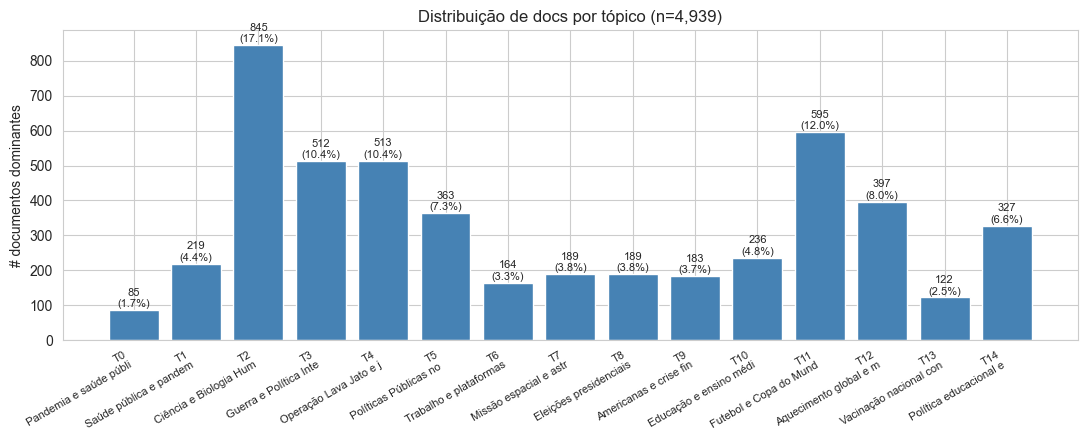


Docs por tópico — descritivas: {'count': 15.0, 'mean': 329.26666666666665, 'std': 210.6138873004568, 'min': 85.0, '25%': 186.0, '50%': 236.0, '75%': 454.5, 'max': 845.0}


In [22]:
# Cell 18 — Bar chart docs por topico
topic_doc_counts = pd.Series(dominant).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
labels = [f"T{tid}\n{names[tid][:22]}" for tid in topic_doc_counts.index]
bars = ax.bar(topic_doc_counts.index, topic_doc_counts.values, color="steelblue")
ax.set_xticks(topic_doc_counts.index); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("# documentos dominantes")
ax.set_title(f"Distribuição de docs por tópico (n={len(docs):,})")
for bar, c in zip(bars, topic_doc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, c + max(topic_doc_counts)*0.01,
            f"{c:,}\n({c/len(docs)*100:.1f}%)", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_docs_por_topico.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'nmf_docs_por_topico.png'}")
plt.show()

print(f"\nDocs por tópico — descritivas: {topic_doc_counts.describe().to_dict()}")


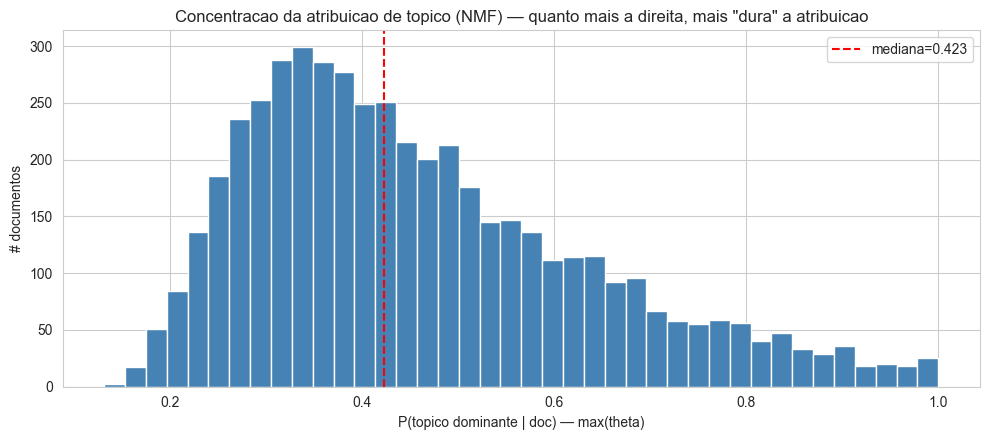

max(theta) — media=0.460, mediana=0.423, % docs com max(theta) < 0.3 (atribuicao difusa): 18.1%


In [23]:
# Histograma da probabilidade do topico dominante (dureza da atribuicao NMF)
_theta_full = np.array(full)
_max_prob = _theta_full.max(axis=1)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(_max_prob, bins=40, color="steelblue", edgecolor="white")
ax.axvline(np.median(_max_prob), color="red", linestyle="--",
           label=f"mediana={np.median(_max_prob):.3f}")
ax.set_xlabel("P(topico dominante | doc) — max(theta)"); ax.set_ylabel("# documentos")
ax.set_title("Concentracao da atribuicao de topico (NMF) — quanto mais a direita, mais \"dura\" a atribuicao")
ax.legend()
plt.tight_layout(); plt.show()

print(f"max(theta) — media={_max_prob.mean():.3f}, mediana={np.median(_max_prob):.3f}, "
      f"% docs com max(theta) < 0.3 (atribuicao difusa): {(_max_prob < 0.3).mean()*100:.1f}%")

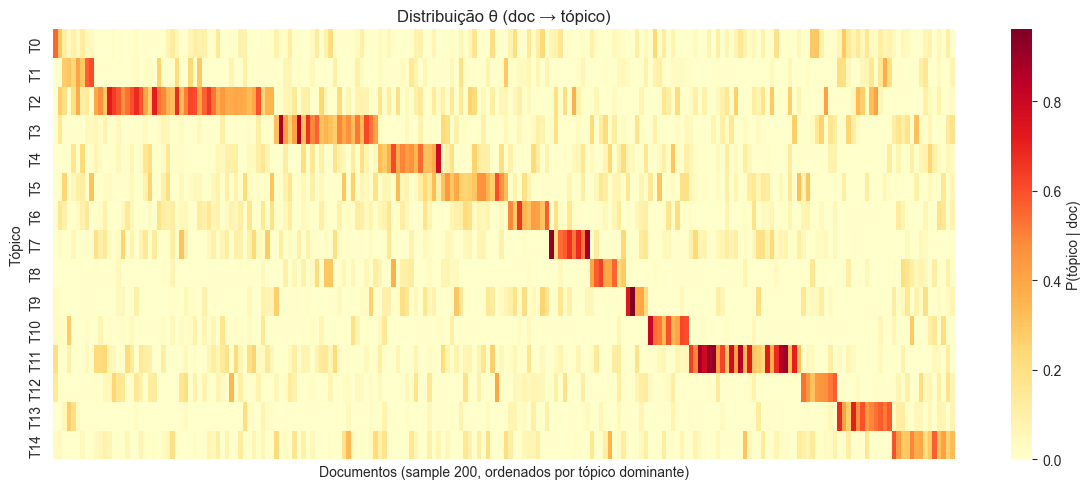

In [24]:
# Cell 19 — Heatmap theta (doc x topico) — sample
sample_n = min(200, len(full))
sample_idx = np.random.RandomState(42).choice(len(full), sample_n, replace=False)
theta_sample = np.array([full[i] for i in sample_idx])

# Sort sample by dominant topic for readability
sample_dom = theta_sample.argmax(axis=1)
order = np.argsort(sample_dom)
theta_sorted = theta_sample[order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(theta_sorted.T, cmap="YlOrRd", cbar_kws={"label": "P(tópico | doc)"},
            xticklabels=False, yticklabels=[f"T{i}" for i in range(BEST_K)], ax=ax)
ax.set_xlabel(f"Documentos (sample {sample_n}, ordenados por tópico dominante)")
ax.set_ylabel("Tópico"); ax.set_title("Distribuição θ (doc → tópico)")
plt.tight_layout(); plt.show()


## t-SNE do espaço de tópicos (θ)

Reduz a matriz θ (N×K) a 2D via t-SNE. Gera PNG colorido por tópico dominante e versão HTML interativa com hover do texto.


Calculando t-SNE sobre matriz theta...


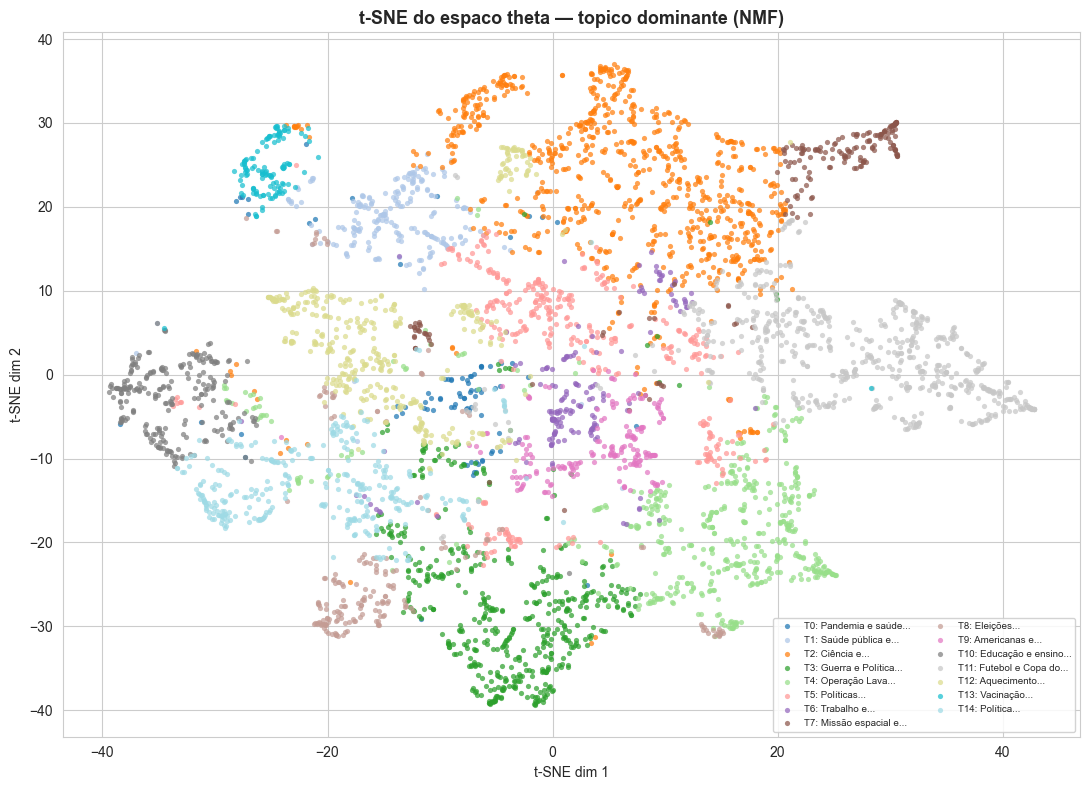

Salvo: ..\data\output\folha\nmf\folha_20260824_183512\nmf_tsne_theta_topico.png


Salvo: ..\data\output\folha\nmf\folha_20260824_183512\nmf_tsne_theta_interactive.html


In [25]:
import plotly.express as px
from sklearn.manifold import TSNE

_theta_mat = np.array(full)  # (n_docs, K)
_texts_nmf = [t[:100] + "..." if len(t) > 100 else t for t in docs]

print("Calculando t-SNE sobre matriz theta...")
_tsne = TSNE(n_components=2, perplexity=30, random_state=seed, max_iter=500)
_theta_2d = _tsne.fit_transform(_theta_mat)

_cmap_nmf = plt.get_cmap("tab20", max(BEST_K, 1))

# PNG por topico dominante
fig, ax = plt.subplots(figsize=(11, 8))
for tid in range(BEST_K):
    _mm = np.array(dominant) == tid
    if _mm.any():
        import textwrap as _tw_u
        _nm = _tw_u.shorten(str(names.get(tid, "")), 20, placeholder="...")
        ax.scatter(_theta_2d[_mm, 0], _theta_2d[_mm, 1],
                   c=[_cmap_nmf(tid)], s=14, alpha=0.72, linewidths=0,
                   label=f"T{tid}: {_nm}")
ax.set_title("t-SNE do espaco theta — topico dominante (NMF)", fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(loc="best", fontsize=7, framealpha=0.85, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_tsne_theta_topico.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'nmf_tsne_theta_topico.png'}")

# HTML interativo por topico dominante
import textwrap as _tw_u2
_tsne_df_nmf = pd.DataFrame({
    "x": _theta_2d[:, 0], "y": _theta_2d[:, 1],
    "Texto": _texts_nmf,
    "Topico": [f"T{t}: {_tw_u2.shorten(str(names.get(t,"")), 25, placeholder="...")}" for t in dominant],
})
fig_u = px.scatter(
    _tsne_df_nmf, x="x", y="y", color="Topico",
    hover_data={"x": False, "y": False, "Texto": True},
    title="t-SNE espaco theta — topico dominante (interativo, NMF)",
    labels={"x": "t-SNE dim 1", "y": "t-SNE dim 2"}, opacity=0.72,
)
fig_u.update_traces(marker_size=5)
_out_u = OUTPUT_DIR / "nmf_tsne_theta_interactive.html"
fig_u.write_html(_out_u)
fig_u.show()
print(f"Salvo: {_out_u}")


## 11. Cross-tab tópico × categoria Folha

Folha tem categorias editoriais (ex: `politica`, `economia`, `esporte`, `mundo`).
Concentração de um tópico em uma categoria valida coerência semântica.



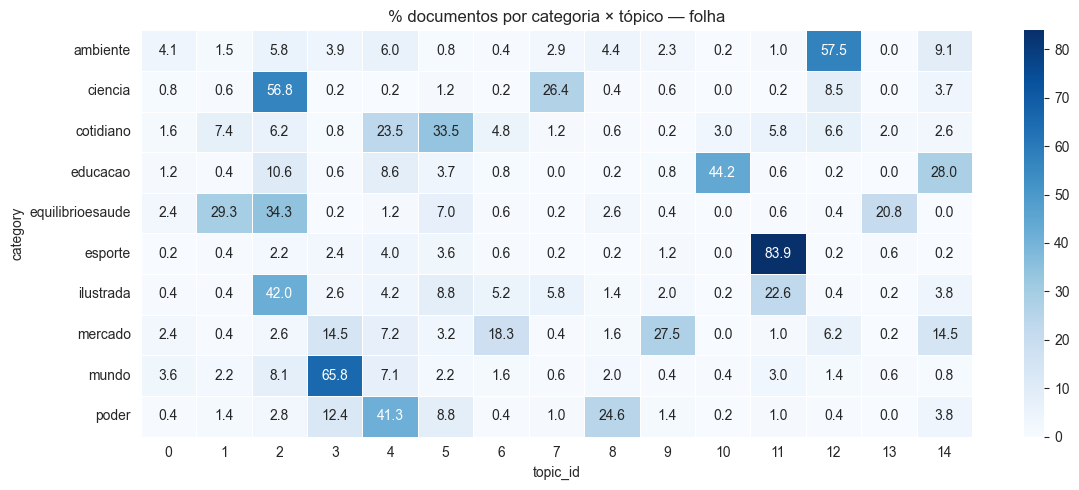

In [26]:
# Heatmap tópico × categoria — folha
if 'category' in df.columns:
    df_topic = df[['category']].copy()
    df_topic['topic_id'] = dominant
    df_topic = df_topic[df_topic['topic_id'] != -1]
    pivot = df_topic.groupby(['category', 'topic_id']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns)*0.8), max(4, len(pivot)*0.5)))
    sns.heatmap(pivot_pct.round(1), annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.5, ax=ax)
    ax.set_title('% documentos por categoria × tópico — folha')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'nmf_topic_category.png', dpi=150)
    plt.show()
else:
    print('Coluna category nao encontrada')



## Evolução temporal dos tópicos

Participação média (θ) de cada tópico por mês, usando a coluna `date` do
corpus — mostra picos e declive de cada tema ao longo da janela 2018-2024.

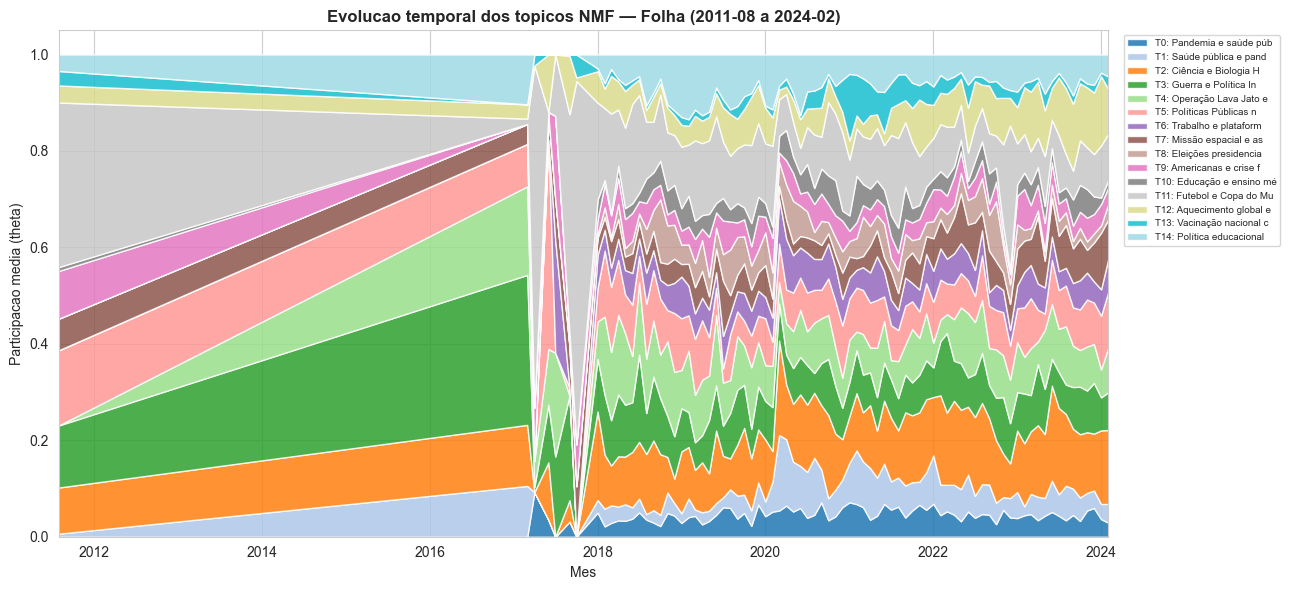

Salvo: ..\data\output\folha\nmf\folha_20260824_183512\nmf_topics_over_time.png


In [27]:
# Evolucao temporal dos topicos (folha: coluna date)
_df_time = df[["data"]].copy()
_df_time["data"] = pd.to_datetime(_df_time["data"], errors="coerce")
_theta_time = np.array(full)  # (n_docs, K), mesma ordem de df

_valid_date = _df_time["data"].notna()
if _valid_date.sum() == 0:
    print("Coluna date sem valores parseaveis — pulando evolucao temporal.")
else:
    _df_time = _df_time[_valid_date].copy()
    _theta_time = _theta_time[_valid_date.values]
    _df_time["month"] = _df_time["data"].dt.to_period("M").dt.to_timestamp()

    _theta_by_month = pd.DataFrame(_theta_time, columns=[f"T{tid}" for tid in range(BEST_K)])
    _theta_by_month["month"] = _df_time["month"].values
    _monthly_share = _theta_by_month.groupby("month").mean().sort_index()

    fig, ax = plt.subplots(figsize=(13, 6))
    _cmap_time = plt.get_cmap("tab20", max(BEST_K, 1))
    ax.stackplot(_monthly_share.index, [_monthly_share[f"T{tid}"] for tid in range(BEST_K)],
                 labels=[f"T{tid}: {names[tid][:20]}" for tid in range(BEST_K)],
                 colors=[_cmap_time(tid) for tid in range(BEST_K)], alpha=0.85)
    ax.set_xlabel("Mes"); ax.set_ylabel("Participacao media (theta)")
    ax.set_title(f"Evolucao temporal dos topicos NMF — Folha "
                 f"({_monthly_share.index.min():%Y-%m} a {_monthly_share.index.max():%Y-%m})",
                 fontsize=12, fontweight="bold")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
    ax.set_xlim(_monthly_share.index.min(), _monthly_share.index.max())
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "nmf_topics_over_time.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Salvo: {OUTPUT_DIR / 'nmf_topics_over_time.png'}")

## pyLDAvis — visualização interativa (API genérica)

O adapter `pyLDAvis.gensim_models` exige o *state* Dirichlet do `LdaModel`
(inferência variacional) — o `gensim.models.Nmf` não o implementa. Usamos a
API genérica `pyLDAvis.prepare()`, que aceita `φ` (tópico×palavra) e `θ`
(doc×tópico) como matrizes cruas: exatamente o dado que o adapter do LDA
calcula por baixo dos panos. Mesma leitura de `02_lda_folha.ipynb`:

- **Esquerda**: tópicos como círculos no plano 2D (PCoA). Tamanho = prevalência,
  distância = dissimilaridade.
- **Direita**: bar chart das top-30 palavras do tópico selecionado, com slider
  λ controlando "exclusivity vs frequency" (Bischof & Airoldi 2016).

In [28]:
# pyLDAvis (API generica, interativo, salva HTML)
import pyLDAvis

pyLDAvis.enable_notebook()

print("Preparing pyLDAvis (API generica, ~30s)...")
_phi_vis = model.get_topics()  # (K, vocab_size)
_phi_vis = _phi_vis / _phi_vis.sum(axis=1, keepdims=True)  # garante soma=1 por linha

_theta_vis = np.array(full)  # (n_docs, K)
_zero_rows = _theta_vis.sum(axis=1) == 0
if _zero_rows.any():
    # docs sem massa de topico (raro, corpus muito esparso): fallback uniforme
    # para nao violar a validacao de pyLDAvis (cada linha de theta deve somar 1)
    _theta_vis[_zero_rows] = 1.0 / _theta_vis.shape[1]
_theta_vis = _theta_vis / _theta_vis.sum(axis=1, keepdims=True)

_doc_lengths = np.array([sum(cnt for _, cnt in bow) for bow in corpus_bow])
_vocab_vis = [dictionary[i] for i in range(len(dictionary))]
_term_freq = np.zeros(len(dictionary))
for bow in corpus_bow:
    for wid, cnt in bow:
        _term_freq[wid] += cnt

vis_data = pyLDAvis.prepare(
    topic_term_dists=_phi_vis,
    doc_topic_dists=_theta_vis,
    doc_lengths=_doc_lengths,
    vocab=_vocab_vis,
    term_frequency=_term_freq,
    sort_topics=False,
)
out_html = f"{out_dir}/nmf_pyldavis_K{BEST_K}.html"
pyLDAvis.save_html(vis_data, out_html)
print(f"Salvo: {out_html}")
vis_data

Preparing pyLDAvis (API generica, ~30s)...


d:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning:

divide by zero encountered in log

d:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning:

divide by zero encountered in log

d:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning:

divide by zero encountered in log



Salvo: ..\data\output\folha\nmf\folha_20260824_183512/nmf_pyldavis_K15.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.012662  0.144911       1        1   4.657164
1     -0.129909  0.124865       2        1   5.443054
2      0.176822  0.051152       3        1  13.961537
3      0.003694 -0.107042       4        1   8.861929
4     -0.095215 -0.161580       5        1   8.987868
5      0.013788 -0.100757       6        1   7.431254
6      0.034538  0.055905       7        1   5.900710
7      0.226090 -0.002682       8        1   5.369996
8     -0.121239 -0.246958       9        1   4.409144
9     -0.094902  0.098072      10        1   4.165004
10     0.023546  0.043515      11        1   3.789942
11     0.192580 -0.127964      12        1   9.740196
12     0.077505  0.157271      13        1   7.894268
13    -0.201611  0.124306      14        1   2.501534
14    -0.118347 -0.053012      15        1   6.886399, topic_info=            Term         Freq        Total Category  logprob  loglift
50          país  6897.000000  6897.000000  Default  30.0000  30.0000
1240   bolsonaro  4181.000000  4181.000000  Default  29.0000  29.0000
122       brasil  6651.000000  6651.000000  Default  28.0000  28.0000
1340     governo  6765.000000  6765.000000  Default  27.0000  27.0000
65         saúde  3519.000000  3519.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
1470      social   478.011709  2395.946209  Topic15  -5.4894   1.0637
109        atual   383.956777  1380.012601  Topic15  -5.7085   1.3963
330   presidente   518.266325  4859.722729  Topic15  -5.4086   0.4374
2687      ensino   394.258120  1773.922247  Topic15  -5.6820   1.1717
1441        rede   369.965490  2327.909753  Topic15  -5.7456   0.8363

[1163 rows x 6 columns], token_table=       Topic      Freq     Term
term                           
8431       3  0.979765   abelha
8431      13  0.022395   abelha
14915      6  0.980213  abertos
14915     13  0.030632  abertos
8015       5  0.011836    abono
...      ...       ...      ...
77        10  0.022689   último
77        11  0.005993   último
77        12  0.190503   último
77        13  0.141700   último
77        15  0.041525   último

[3721 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])

## Top documentos por tópico

Mostra os 3 docs com maior probabilidade em cada tópico — verificação qualitativa direta da semântica.


In [29]:
# Cell 22 — Top 3 docs por topico
TOP_N_DOCS = 3
TRUNC = 200

theta_arr = np.array(full)
print("Top docs por topico (truncados em 200 chars):\n")
for tid in sorted(topics_keywords):
    top_idx = np.argsort(theta_arr[:, tid])[::-1][:TOP_N_DOCS]
    print(f"=== T{tid} [{names[tid]}] ===")
    print(f"  keywords: {topics_keywords[tid][:8]}\n")
    for rank, idx in enumerate(top_idx, 1):
        prob = theta_arr[idx, tid]
        cat = df.iloc[idx]["category"]
        text = df.iloc[idx]["message"][:TRUNC].replace("\n", " ")
        print(f"  #{rank} (P={prob:.3f}, cat={cat}): {text}...")
        print()


Top docs por topico (truncados em 200 chars):

=== T0 [Pandemia e saúde pública no Brasil] ===
  keywords: ['país', 'brasil', 'pessoa', 'brasileiro', 'dose', 'acordo', 'vacina', 'população']

  #1 (P=0.641, cat=mundo): Durante um longo tempo da pandemia de Covid-19, o turista brasileiro teve sua entrada vetada em vários países do mundo devido à alta incidência do coronavírus, à vacinação lenta e à circulação de nova...

  #2 (P=0.553, cat=cotidiano): O Brasil caiu uma posição no ranking global do IDH (Índice de Desenvolvimento Humano) em 2018. Agora, o país ocupa o 79º lugar em um grupo de 189 países e territórios —no ano anterior, avaliação corri...

  #3 (P=0.496, cat=mundo): O governo argentino decidiu estender o fechamento das fronteiras aéreas e terrestres com o Brasil até, pelo menos, dia 12 de março. A nova ministra da saúde, Carla Vizzotti, que assumiu no lugar de Gi...

=== T1 [Saúde pública e pandemia no Brasil] ===
  keywords: ['saúde', 'caso', 'dado', 'ministério', 'doença'

## 12. Export + relatório qualitativo

Gera os CSVs canônicos (`nmf_results.csv`, `nmf_topics_for_eval.csv`, `nmf_metrics.csv`).


In [30]:
# Cell 23 — Export final
os.makedirs(out_dir, exist_ok=True)

export_results(
    topics=dominant, probs=full, names=names, texts=docs,
    output_path=f"{out_dir}/nmf_results.csv",
    topic_type="probabilistic", granularity="unit", post_ids=post_ids,
)
export_topics_for_eval(
    topics_keywords=topics_keywords, topics_names=names,
    model_name="nmf", output_path=f"{out_dir}/nmf_topics_for_eval.csv",
)
metrics_full = {**metrics, "k_grid_scores": json.dumps(scores),
                "k_npmi_scores": json.dumps(npmi_scores),
                # curva de Diversity sobre a faixa de K — segundo eixo da fronteira
                # de Pareto do protocolo 2026-08-22/23 (secao 1.6).
                "k_diversity_scores": json.dumps(div_scores),
                "reconstruction_error": reconstruction_error, "grid_passes": 20,
                "best_kappa": best_kappa, "best_min_prob": best_min_prob}
pd.DataFrame([metrics_full]).to_csv(f"{out_dir}/nmf_metrics.csv", index=False)
# Cache acessível em próximos runs (foi salvo no run dir; copia pro diretório-base)
pd.DataFrame([metrics_full]).to_csv(f"{BASE_OUTPUT_DIR}/nmf_metrics.csv", index=False)

print(f"CSVs em {out_dir}/:")
for f in ["nmf_results.csv", "nmf_topics_for_eval.csv", "nmf_metrics.csv"]:
    sz = os.path.getsize(f"{out_dir}/{f}")
    print(f"  {f} ({sz/1024:.0f} KB)")

# Matriz beta completa (tópico × vocabulário) — habilita retrofits sem refit
_beta = model.get_topics()  # (K, vocab_size)
_vocab = [dictionary[i] for i in range(len(dictionary))]
pd.DataFrame(_beta, columns=_vocab).to_csv(f"{out_dir}/nmf_beta.csv", index_label="topic_id")
print(f"Salvo: {out_dir}/nmf_beta.csv ({_beta.shape[0]}x{_beta.shape[1]})")


CSVs em ..\data\output\folha\nmf\folha_20260824_183512/:
  nmf_results.csv (25595 KB)
  nmf_topics_for_eval.csv (2 KB)
  nmf_metrics.csv (1 KB)
Salvo: ..\data\output\folha\nmf\folha_20260824_183512/nmf_beta.csv (15x17331)


In [31]:
# Cell 24 — Exclusividade + n_docs por tópico (ranking p/ o assessor de calibração)
# Espelha o bertopic_exclusividade_ranking.csv. Reusa os MESMOS topic_word_scores
# nativos (phi/beta) do cálculo de exclusividade do nmf_metrics.csv, p/ o ranking
# BATER com as métricas (mesma convenção do BERTopic). Coletado pelo advisor via
# glob *exclusividade_ranking.csv.
from _helpers import export_exclusividade_ranking

excl_rank_df = export_exclusividade_ranking(
    topics_keywords=topics_keywords,
    dominant_per_doc=dominant,
    names=names,
    topic_word_scores=_topic_word_scores_nmf,
    out_path=f"{out_dir}/nmf_exclusividade_ranking.csv",
    top_n=params["evaluation"].get("top_n_keywords_metrics", 20),
)
print("nmf_exclusividade_ranking.csv (exclusividade desc):")
print(excl_rank_df.to_string(index=False))

nmf_exclusividade_ranking.csv (exclusividade desc):
 topic_id                                topic_name  exclusividade  n_docs
        7             Missão espacial e astronautas       0.804694     189
       10         Educação e ensino médio no Brasil       0.785731     236
        9             Americanas e crise financeira       0.672606     183
       11         Futebol e Copa do Mundo no Brasil       0.656510     595
        6 Trabalho e plataformas digitais no Brasil       0.629833     164
       12  Aquecimento global e mudanças climáticas       0.588538     397
        5 Políticas Públicas no Estado de São Paulo       0.551533     363
        1        Saúde pública e pandemia no Brasil       0.512013     219
       13        Vacinação nacional contra Covid-19       0.503370     122
        8        Eleições presidenciais brasileiras       0.500251     189
        3           Guerra e Política Internacional       0.472495     512
        2                 Ciência e Biologia Hum

In [32]:
# Cell 24 — Relatorio qualitativo (template)
md = qualitative_report(topics_keywords, names)
print(md)


# Qualitative report
**Total topics:** 15
## Tópicos coesos
_(preencher manualmente: tópicos com keywords semanticamente próximas e tema único)_
## Tópicos genéricos / discurso
_(preencher manualmente: keywords genéricas, sem tema concreto)_
## Tópicos lixo / boilerplate
_(preencher manualmente: keywords são fórmulas, hashtags, headers, etc.)_
## Redundâncias
_(preencher manualmente: tópicos diferentes que cobrem o mesmo tema)_
## Candidatos a stop word
_(preencher manualmente: termos repetidos em 3+ tópicos sem agregar diferenciação)_
## Tabela de tópicos
| ID | Nome | Top keywords |
|---|---|---|
| T0 | Pandemia e saúde pública no Brasil | país, brasil, pessoa, brasileiro, dose, acordo, vacina, população, mundo, vacinar |
| T1 | Saúde pública e pandemia no Brasil | saúde, caso, dado, ministério, doença, paciente, morte, médico, pandemia, criança |
| T2 | Ciência e Biologia Humana | pessoa, estudo, mulher, pesquisa, universidade, humano, pesquisador, vida, animal, paciente |
| T3 | Gu

## Próximos passos
- Comparar com LDA (`02_lda_folha.ipynb`) e BERTopic (`01_bertopic_folha.ipynb`) — triangulação LDA × NMF × BERTopic
- Analisar evolução temporal de tópicos (coluna `date` disponível)

## Referências

- Lee, D. D., Seung, H. S. (1999). *Learning the parts of objects by non-negative matrix factorization*. Nature.
- Roder, M., Both, A., Hinneburg, A. (2015). *Exploring the Space of Topic Coherence Measures*. WSDM — c_v.
- Stevens, K. et al. (2012). *Exploring topic coherence over many models and many topics*. EMNLP — limitações de c_v com K alto.
- Dieng, A. B., Ruiz, F. J. R., Blei, D. M. (2020). *Topic Modeling in Embedding Spaces*. TACL — Topic Diversity.
